# Machine Learning Models to Predict Student Enrolled at University of Wisconsin Oshkosh

## Data Extraction with SQL

In [31]:
from dotenv import load_dotenv
import os
import psycopg2  # pip install psycopg2-binary
import pandas as pd
# Load from your private path
load_dotenv(dotenv_path=r"C:\Users\huynhd\.secrets\data.env")  # <-- update the path

import oracledb

def connect_oracle(user_key: str):
    key = user_key.upper()
    user_env = f"ORACLE_USER_{key}"
    pass_env = f"ORACLE_PASS_{key}"
    dsn_env  = f"ORACLE_DSN_{key}"

    username = os.getenv(user_env)
    password = os.getenv(pass_env)
    dsn      = os.getenv(dsn_env) or os.getenv("ORACLE_DSN")
    lib_dir  = os.getenv("ORACLE_LIB_DIR", r"C:\Du\instantclient_21_18")

    missing = []
    if not username: missing.append(user_env)
    if not password: missing.append(pass_env)
    if not dsn:      missing.append(f"{dsn_env} or ORACLE_DSN")
    if missing:
        raise RuntimeError(f"Missing env vars: {', '.join(missing)}")

    oracledb.init_oracle_client(lib_dir=lib_dir)
    return oracledb.connect(user=username, password=password, dsn=dsn)

# Example usage
with connect_oracle("HUYNHD") as conn:
    with conn.cursor() as cur:
        cur.execute("SELECT USER, SYSDATE FROM DUAL")
        print(cur.fetchone())
connection = connect_oracle("HUYNHD")

# Run a query
query = """
-- I - Generate applications, admission and accepted
-- 1. Assign the same acad_prog and campus for each matr in one ADM_APPL_NBR
WITH AcadPlanName AS (
    SELECT 
        p.EMPLID,
        p.ACAD_CAREER,
        p.ADM_APPL_NBR,
        p.ACAD_PLAN,
        p.EFFDT,        
        p.scc_row_add_dttm,
        p.EFFSEQ,
        t.DESCR,
        t."DEGREE"
    FROM PS_ADM_APPL_PLAN p
    JOIN (
        SELECT 
            ACAD_PLAN,
            DESCR,
            "DEGREE",
            ROW_NUMBER() OVER (
                PARTITION BY ACAD_PLAN
                ORDER BY EFFDT DESC
            ) AS rn
        FROM PS_ACAD_PLAN_TBL
    ) t ON p.ACAD_PLAN = t.ACAD_PLAN AND t.rn = 1
--    WHERE p.EMPLID = '0988990' 
),

AcadProgPlan AS (
		SELECT 
			g.EMPLID,
			g.ACAD_CAREER,
			g.ADM_APPL_NBR,
			g.EFFDT,
            g.ACTION_DT,
            CASE 
            	WHEN g.PROG_STATUS = 'AP' THEN g.ACTION_DT
            	ELSE NULL 
            END AS APPLIED_DT,
            CASE 
            	WHEN g.PROG_STATUS = 'AD' THEN g.ACTION_DT
            	WHEN g.PROG_STATUS = 'CN' THEN g.ACTION_DT            	
            	ELSE NULL 
            END AS DECISION_DT,
            CASE 
            	WHEN g.PROG_STATUS = 'AC' THEN g.ACTION_DT
            	ELSE NULL 
            END AS ACCEPTED_DT,   
            g.scc_row_add_dttm,
			g.INSTITUTION,
			g.ACAD_PROG,
			g.PROG_STATUS,
			g.PROG_ACTION,
			g.ADMIT_TERM,
			g.CAMPUS,
			l."DEGREE",
			l.DESCR,
			l.ACAD_PLAN
		FROM PS_ADM_APPL_prog g
		JOIN AcadPlanName l ON g.ADM_APPL_NBR = l.ADM_APPL_NBR  AND g.EFFSEQ = l.EFFSEQ AND g.EFFDT = l.EFFDT
--		WHERE g.emplid = '0819389'
		ORDER BY g.ADMIT_TERM desc, g.ADM_APPL_NBR, g.EFFDT
),

ProgHistory AS (
    SELECT
        a.CAMPUS,
        a.ACAD_CAREER,
        a.ADMIT_TERM,
        a.EMPLID,
        a.ADM_APPL_NBR,
        a.ACAD_PROG,
        a."DEGREE",
        a.DESCR,
        a.PROG_ACTION,
        a.PROG_STATUS,
        a.ACAD_PLAN,
		a.EFFDT,
        a.ACTION_DT,
        a.scc_row_add_dttm,
        a.APPLIED_DT,
        a.DECISION_DT, 
        a.ACCEPTED_DT,
        CASE WHEN a.PROG_ACTION = 'MATR' THEN a.ACAD_PROG END AS Matr_Prog,
        CASE WHEN a.PROG_ACTION = 'MATR' THEN a.CAMPUS END AS Matr_Campus,
        CASE WHEN a.PROG_ACTION = 'MATR' THEN a.ACAD_PLAN END AS Matr_Plan,
        CASE WHEN a.PROG_ACTION = 'MATR' THEN a.DESCR END AS Matr_Descr,
        CASE WHEN a.PROG_ACTION = 'MATR' THEN a.EFFDT END AS Matr_Effdt,        
        CASE WHEN a.PROG_ACTION = 'MATR' THEN a."DEGREE" END AS Matr_Degree                
    FROM AcadProgPlan a
),

Propagated AS (
    SELECT
        CAMPUS,
        ACAD_CAREER,
        ADMIT_TERM,
        EMPLID,
        ADM_APPL_NBR,
        ACAD_PROG,
        PROG_ACTION,
        PROG_STATUS,
        ACAD_PLAN,
        "DEGREE",
        DESCR,
        EFFDT,
        ACTION_DT,
        scc_row_add_dttm,
        APPLIED_DT,
        DECISION_DT, 
        ACCEPTED_DT,
        COALESCE(
            LAST_VALUE(Matr_Prog IGNORE NULLS) OVER (
                PARTITION BY ADM_APPL_NBR
                ORDER BY EFFDT
                ROWS BETWEEN CURRENT ROW AND UNBOUNDED FOLLOWING
            ),
            LAST_VALUE(ACAD_PROG) OVER (
                PARTITION BY ADM_APPL_NBR
                ORDER BY EFFDT
                ROWS BETWEEN CURRENT ROW AND UNBOUNDED FOLLOWING
            )
        ) AS Effective_Prog,
		COALESCE(
            LAST_VALUE(Matr_Campus IGNORE NULLS) OVER (
                PARTITION BY ADM_APPL_NBR
                ORDER BY EFFDT
                ROWS BETWEEN CURRENT ROW AND UNBOUNDED FOLLOWING
            ),
            LAST_VALUE(CAMPUS) OVER (
                PARTITION BY ADM_APPL_NBR
                ORDER BY EFFDT
                ROWS BETWEEN CURRENT ROW AND UNBOUNDED FOLLOWING
            )
        ) AS Effective_Campus,
		COALESCE(
            LAST_VALUE(Matr_Plan IGNORE NULLS) OVER (
                PARTITION BY ADM_APPL_NBR
                ORDER BY EFFDT
                ROWS BETWEEN CURRENT ROW AND UNBOUNDED FOLLOWING
            ),
            LAST_VALUE(ACAD_PLAN) OVER (
                PARTITION BY ADM_APPL_NBR
                ORDER BY EFFDT
                ROWS BETWEEN CURRENT ROW AND UNBOUNDED FOLLOWING
            )
        ) AS Effective_Plan,   
        COALESCE(
            LAST_VALUE(Matr_Effdt IGNORE NULLS) OVER (
                PARTITION BY ADM_APPL_NBR
                ORDER BY EFFDT
                ROWS BETWEEN CURRENT ROW AND UNBOUNDED FOLLOWING
            ),
            LAST_VALUE(EFFDT) OVER (
                PARTITION BY ADM_APPL_NBR
                ORDER BY EFFDT
                ROWS BETWEEN CURRENT ROW AND UNBOUNDED FOLLOWING
            )
        ) AS Effective_Effdt,  
		COALESCE(
            LAST_VALUE(Matr_Degree IGNORE NULLS) OVER (
                PARTITION BY ADM_APPL_NBR
                ORDER BY EFFDT
                ROWS BETWEEN CURRENT ROW AND UNBOUNDED FOLLOWING
            ),
            LAST_VALUE("DEGREE") OVER (
                PARTITION BY ADM_APPL_NBR
                ORDER BY EFFDT
                ROWS BETWEEN CURRENT ROW AND UNBOUNDED FOLLOWING
            )
        ) AS Effective_Degree,  
		COALESCE(
            LAST_VALUE(Matr_Descr IGNORE NULLS) OVER (
                PARTITION BY ADM_APPL_NBR
                ORDER BY EFFDT
                ROWS BETWEEN CURRENT ROW AND UNBOUNDED FOLLOWING
            ),
            LAST_VALUE(DESCR) OVER (
                PARTITION BY ADM_APPL_NBR
                ORDER BY EFFDT
                ROWS BETWEEN CURRENT ROW AND UNBOUNDED FOLLOWING
            )
        ) AS Effective_Descr          
    FROM ProgHistory
),

-- 2. Getting unique emplid by CAMPUS, ADMIT_TERM, EMPLID, ADM_APPL_NBR, ACAD_PROG, and ADMIT_TYPE

Application AS (
		SELECT 
		    max(a.CAMPUS) AS ORIRINAL_CAMPUS,
		    a.EFFECTIVE_CAMPUS AS CAMPUS,
			a.ADMIT_TERM,
            a.ACAD_CAREER,
		    a.EMPLID,
		    b.ADMIT_TYPE,
		    a.ADM_APPL_NBR,
		    MAX(a.ACAD_PROG) AS ORIGINAL_PROG,
		    a.Effective_Prog AS ACAD_PROG, -- Effective_Prog
			MAX(a.ACAD_PROG) AS ORIGINAL_PLAN,
		    a.Effective_Plan AS ACAD_PLAN,
			MAX(a.EFFDT) AS ORIGINAL_EFFDT,
		    a.Effective_Effdt AS EFFDT,	
            MAX(a.scc_row_add_dttm) AS scc_row_add_dttm,
            MAX(a.ACTION_DT) AS ACTION_DT,
            MIN(a.APPLIED_DT) AS APPLIED_DT,
	        MIN(a.DECISION_DT) AS DECISION_DT, 
	        MAX(a.ACCEPTED_DT) AS ACCEPTED_DT,
   			MAX(a."DEGREE") AS ORIGINAL_DEGREE,
		    a.Effective_Degree AS "DEGREE",
			MAX(a.DESCR) AS ORIGINAL_DESCR,
		    a.Effective_Descr AS DESCR,		    
		    max(CASE 
			    WHEN a.PROG_STATUS = 'AC' THEN a.EMPLID
			    WHEN a.PROG_STATUS = 'AD' THEN a.EMPLID 
			    ELSE null 
			END) AS Admitted,
			max(CASE 
			    WHEN a.PROG_STATUS = 'AC' THEN a.EMPLID 
			    ELSE null 
			END) AS Accepted	
		FROM Propagated a
		JOIN ps_adm_appl_data b
		    ON a.adm_appl_nbr = b.adm_appl_nbr    
		WHERE
			TRIM(a.ADM_APPL_NBR) IS NOT NULL
		GROUP BY     
				a.EFFECTIVE_CAMPUS,
                a.ACAD_CAREER,
				a.ADMIT_TERM,
			    a.emplid,
			    a.ADM_APPL_NBR,
			    a.Effective_Plan,
			    a.Effective_Prog,
			    a.Effective_Descr,
			    a.Effective_Effdt,
			    a.Effective_Degree,		
				b.ADMIT_TYPE	
		ORDER BY a.emplid, a.ADMIT_TERM
    
),

--SELECT *
--FROM Application
--WHERE EMPLID = '0166171' -- ADM_APPL_NBR = '00396313'  AND ACAD_PLAN  = 'J26102222'
----ORDER BY EMPLID,ADM_APPL_NBR


-- II. Program change in August 2025 and the latest changes
-- 1. Program change in August 2025

ProgChangeAU25 AS (
		SELECT 	
			ADM_APPL_NBR, 
			ACAD_PROG 
		FROM ps_ACAD_PROG 
		WHERE 
			PROG_REASON = 'RSTR'
			AND EFFSEQ = 1
			AND TRIM(ADM_APPL_NBR) IS NOT NULL
			AND EFFDT = TO_DATE('2025-08-10 00:00:00', 'YYYY-MM-DD HH24:MI:SS')  			
),

-- 2. Latest change of program
ProgChangeLast AS (
		SELECT 	
			a.ADM_APPL_NBR, 
			a.ACAD_PROG 
		FROM ps_ACAD_PROG a
		WHERE 
			TRIM(a.ADM_APPL_NBR) IS NOT NULL
--			AND a.emplid = '0967572'
			AND a.EFFDT = (
				    SELECT MAX(b.EFFDT)
				    FROM PS_ACAD_PROG b
				    WHERE b.EMPLID = a.EMPLID)			
),


-- III. Acad_plan
-- 1. Getting


AcadPlans AS (
		SELECT
		    a.EMPLID,
		    a.ACAD_PROG,
		    a.ADM_APPL_NBR,
		    MAX(a.EFFDT) AS LATEST_EFFDT,
		    MIN(a.EFFDT) AS EARLIEST_EFFDT,
		    MAX(CASE WHEN a.EFFDT = latest_effdt THEN p.ACAD_PLAN END) AS LATEST_PLAN,
		    MAX(CASE WHEN a.EFFDT = latest_effdt THEN p."DEGREE" END) AS "DEGREE",
		    MAX(CASE WHEN a.EFFDT = latest_effdt THEN p.DESCR END) AS DESCR,
		    MAX(CASE WHEN a.EFFDT = earliest_effdt THEN p.ACAD_PLAN END) AS EARLIEST_PLAN,
		    MAX(CASE WHEN a.EFFDT = earliest_effdt THEN p.DESCR END) AS DESCR_EARLIEST
		FROM (
		    SELECT 
		        a.EMPLID,
			    a.ACAD_PROG,
			    a.ADM_APPL_NBR,
			    a.EFFDT,
		        MAX(a.EFFDT) OVER (PARTITION BY a.EMPLID, a.ACAD_PROG, a.ADM_APPL_NBR) AS latest_effdt,
		        MIN(a.EFFDT) OVER (PARTITION BY a.EMPLID, a.ACAD_PROG, a.ADM_APPL_NBR) AS earliest_effdt
		    FROM PS_ADM_APPL_PROG a
		) a
		JOIN Application p 
		    ON p.EMPLID = a.EMPLID 
		    AND p.EFFDT = a.EFFDT
		GROUP BY a.EMPLID, a.ACAD_PROG, a.ADM_APPL_NBR		    
)


--SELECT *
--FROM AcadPlans
--WHERE ADM_APPL_NBR = '00396313'  --AND ACAD_PLAN  = 'J26102222'
----ORDER BY EMPLID,ADM_APPL_NBR
,

AppNumberFill AS (
					SELECT
							ma.CAMPUS,
					        ma.ADMIT_TERM,
                            ma.COMPLETION_TERM,
					        ma.EMPLID,
							CASE 
					        	WHEN trim(ma.ADM_APPL_NBR) is NOT NULL THEN ma.ADM_APPL_NBR
					        	ELSE best.ADM_APPL_NBR
					        END AS ADM_APPL_NBR,
					        CASE  
					        	WHEN ma.PROG_STATUS = 'AC' THEN ma.EFFDT 
					        END AS START_DATE,
					        CASE  
					        	WHEN ma.PROG_ACTION IN ('COMP', 'DISC') THEN ma.EFFDT 
					        END AS END_DATE,	
					        CASE  
					        	WHEN ma.PROG_ACTION IN ('COMP') THEN ma.EFFDT 
					        END AS GRAD_DATE,	                            
					        CASE  
					        	WHEN ma.PROG_ACTION IN ('COMP') THEN ma.EMPLID 
					        END AS GRADUATED,	
					        CASE  
					        	WHEN ma.PROG_ACTION IN ('DISC') THEN ma.EMPLID 
					        END AS DISCONTINUED,	                            
					        CASE  
					        	WHEN ma.PROG_STATUS IN ('AC') THEN ma.ACAD_PROG 
					        END AS ACAD_PROG_START,						        
					        CASE  
					        	WHEN ma.PROG_STATUS IN('CM', 'DC') THEN ma.ACAD_PROG 
					        END AS ACAD_PROG_END,		        
					        ma.ACAD_CAREER,
					        ma.ACAD_PROG,
					        ma.PROG_STATUS,
					        ma.PROG_ACTION,
					        ma.PROG_REASON,
					        ma.EFFSEQ,
					        ma.EFFDT
					FROM PS_ACAD_PROG ma
					OUTER APPLY (
					    SELECT a.ADM_APPL_NBR
					    FROM PS_ADM_APPL_PROG a
					    WHERE a.EMPLID = ma.EMPLID 
					    	AND a.ACAD_CAREER = ma.ACAD_CAREER
					      AND a.ADMIT_TERM  <= ma.ADMIT_TERM
					      AND a. PROG_ACTION = 'MATR'
					    ORDER BY a.ADMIT_TERM DESC, a.ADM_APPL_NBR DESC
					    FETCH FIRST 1 ROW ONLY
					) best 
					WHERE 		
							CASE 
					        	WHEN trim(ma.ADM_APPL_NBR) is NOT NULL THEN ma.ADM_APPL_NBR
					        	ELSE best.ADM_APPL_NBR
					        END IS NOT NULL
					        AND ma.PROG_STATUS IN('AC', 'DC', 'CM', 'PRGC')
),

Program AS (SELECT 
					ma.CAMPUS,
			        ma.ADMIT_TERM,
                    MAX(ma.COMPLETION_TERM) AS COMPLETION_TERM,
			        ma.EMPLID,
					ma.ADM_APPL_NBR,
			        ma.ACAD_CAREER,
			        MAX(ma.ACAD_PROG_START) AS ACAD_PROG_START,
			        MAX(CASE 
			        	WHEN ma.ACAD_PROG_END IS NOT NULL THEN ma.ACAD_PROG_END
			        	ELSE ma.ACAD_PROG_START
			        END)  AS ACAD_PROG_END,		
			        MIN(ma.START_DATE) AS START_DATE,
                    MAX(ma.GRAD_DATE) AS GRAD_DATE,
			        MAX(ma.GRADUATED) AS GRADUATED,
                    MAX(ma.DISCONTINUED) AS DISCONTINUED,
   			        CASE WHEN max(ma.END_DATE) IS NULL THEN SYSDATE
			        ELSE max(ma.END_DATE) end
   			        AS END_DATE
			  FROM AppNumberFill ma
			  GROUP BY 					
			  		ma.CAMPUS,
			        ma.ADMIT_TERM,
			        ma.EMPLID,
					ma.ADM_APPL_NBR,
			        ma.ACAD_CAREER
),

Enrolled AS (SELECT
		    a.CAMPUS,
		    s.EMPLID,
		    a.ADM_APPL_NBR,
		    s.ACAD_CAREER,
		    s.ACAD_PROG,
		    a.ACAD_PROG_START,
		    a.ACAD_PROG_END,
		    a.GRADUATED,
		    t.STRM,
		    t.ACAD_YEAR,
		    t.TERM_BEGIN_DT,
		    t.TERM_END_DT,
		    a.START_DATE,
		    a.END_DATE,
		    ROW_NUMBER() OVER (
		        PARTITION BY s.EMPLID, a.START_DATE, a.END_DATE, a.ADM_APPL_NBR
		        ORDER BY t.TERM_BEGIN_DT ASC
		    ) AS rn
		FROM PS_STDNT_ENRL s
		INNER JOIN PS_TERM_TBL t ON s.STRM = t.STRM
		INNER JOIN Program a
		    ON s.EMPLID = a.EMPLID
		   AND t.TERM_BEGIN_DT BETWEEN a.START_DATE AND a.END_DATE
		   AND s.STRM >= a.ADMIT_TERM
		WHERE NOT (
		        s.ENRL_STATUS_REASON = 'DROP'
		        AND s.ENRL_DROP_DT BETWEEN t.TERM_BEGIN_DT AND t.TERM_BEGIN_DT + 14
		    )
),

CurrentEnrolled AS ( 		
		SELECT
		    a.CAMPUS,
		    s.EMPLID,
		    a.ADM_APPL_NBR,
		    s.ACAD_CAREER,
		    s.ACAD_PROG,
		    a.GRADUATED,
		    t.STRM,
		    t.ACAD_YEAR,
		    t.TERM_BEGIN_DT,
		    t.TERM_END_DT,
		    a.START_DATE,
		    a.END_DATE,
		    ROW_NUMBER() OVER (
		        PARTITION BY s.EMPLID, a.START_DATE, a.END_DATE, a.ADM_APPL_NBR
		        ORDER BY t.TERM_BEGIN_DT ASC
		    ) AS rn
		FROM PS_STDNT_ENRL s
		INNER JOIN PS_TERM_TBL t ON s.STRM = t.STRM
		INNER JOIN Program a
		    ON s.EMPLID = a.EMPLID
		   AND t.TERM_BEGIN_DT BETWEEN a.START_DATE AND a.END_DATE
		   AND s.STRM >= a.ADMIT_TERM
		WHERE NOT (
		        s.ENRL_STATUS_REASON = 'DROP'
		        AND s.ENRL_DROP_DT BETWEEN t.TERM_BEGIN_DT AND t.TERM_BEGIN_DT + 14
		    )
        AND a.END_DATE  = SYSDATE
),

car_term_cum AS (
  SELECT
    s.EMPLID,
    MAX(s.acad_year) AS acad_year,
    MAX(NVL(s.tot_cumulative, 0)) AS total_credit
  FROM ps_stdnt_car_term s
  WHERE s.ACAD_LEVEL_BOT IN ('10', '20', '30', '40') 
  AND s.tot_cumulative >= 1
  GROUP BY s.emplid 
  ORDER BY acad_year DESC
),
--SELECT GRADUATED, GRAD_DATE
--FROM Enrolled
--WHERE GRADUATED IS NOT null

StillEnrolled AS (
        	SELECT ACAD_CAREER, EMPLID 
            FROM (
            	SELECT ACAD_CAREER, 	EMPLID,
            	EFFDT,
            	PROG_STATUS,
            	ROW_NUMBER() OVER (PARTITION BY EMPLID ORDER BY EFFDT DESC) AS rn
            	FROM PS_ACAD_PROG)	
            WHERE rn = 1 
            AND PROG_STATUS = 'AC'
),

Completed AS (
        SELECT DISTINCT ACAD_CAREER, EMPLID
        FROM PS_ACAD_DEGR
        WHERE "DEGREE" LIKE 'B%'
),

Retained AS (
    SELECT *
    FROM (
        SELECT
            e.CAMPUS,
            e.EMPLID,
            e.ADM_APPL_NBR,
            e.ACAD_PROG,
            e.START_DATE,
            e.END_DATE,            
            e.ACAD_YEAR,
            e.STRM,
            e.TERM_BEGIN_DT,
            e.TERM_END_DT,    
            fe.EMPLID AS RETAINED,
            ROW_NUMBER() OVER (
                PARTITION BY e.EMPLID, e.CAMPUS, e.ACAD_PROG, e.ADM_APPL_NBR
                ORDER BY e.TERM_BEGIN_DT ASC
            ) AS rn_retained
        FROM Enrolled e
        JOIN Enrolled fe
            ON e.EMPLID = fe.EMPLID
           AND e.ADM_APPL_NBR = fe.ADM_APPL_NBR
           AND TO_NUMBER(e.ACAD_YEAR) = TO_NUMBER(fe.ACAD_YEAR) + 1
           AND e.TERM_BEGIN_DT BETWEEN fe.START_DATE AND fe.END_DATE
           AND fe.rn = 1
           AND e.rn > 1        
    ) sub
    WHERE rn_retained = 1
    AND EMPLID IS NOT NULL 
),


Address AS (
    SELECT EMPLID,
           COUNTRY,
           ADDRESS1 AS ADDRESS,
           CITY,
           UPPER(CASE 
               WHEN COUNTRY <> 'USA' THEN 'IT' 
               WHEN COUNTRY = 'USA' AND trim(STATE) IS NULL THEN 'OT'
               ELSE STATE
            END) AS STATE,
		   SUBSTR(POSTAL, 1, 5) AS ZIPCODE,
           EFFDT,
           ROW_NUMBER() OVER (PARTITION BY EMPLID ORDER BY EFFDT ASC) AS rn
    FROM PS_ADDRESSES
	WHERE ADDRESS_TYPE = 'HOME'
),

RaceType AS ( 
		SELECT 
		    RI.EMPLID,
		    CASE 				   		   
			    WHEN CT.EMPLID IS NULL AND RI.Z_OIRETHNM_SEC_OIR IS NOT NULL THEN 'Two or more'
			    WHEN CT.EMPLID IS NULL THEN RI.Z_OIRETHNM_PRI_OIR
			    ELSE 'International'
		    END AS RACE
		FROM PS_Z_SCC_ETH_PS_VW RI
		LEFT JOIN (
		    SELECT DISTINCT EMPLID
		    FROM PS_SCC_CITIZEN_QVW
		    WHERE COUNTRY <> 'USA'
		) CT ON CT.EMPLID = RI.EMPLID	
	),

FinancialAid AS (
    SELECT
        SA.EMPLID,
        SA.ACAD_CAREER,
        SUM(NVL(SA.DISBURSED_AMOUNT, 0))
          - SUM(CASE WHEN SA.FIN_AID_TYPE = 'L' THEN NVL(SA.DISBURSED_AMOUNT, 0) ELSE 0 END) AS Financial_aid_wl
    FROM PS_STDNT_AWARDS SA
    WHERE TRIM(FIN_AID_TYPE) IS NOT NULL
    AND SA.DISBURSED_AMOUNT > 0
    GROUP BY SA.EMPLID, SA.ACAD_CAREER  
),    

SchoolAcadPlan as ( 
        SELECT 
          COALESCE(a.ACAD_PLAN, b.ACAD_PLAN) AS ACAD_PLAN,  -- the unioned ID
          CASE 
          	WHEN  b.ACAD_ORG IS NULL THEN 'OTHER'
          	ELSE b.ACAD_ORG
          END AS ACAD_ORG, 
          CASE 
          	WHEN  b.ACAD_ORG IS NULL THEN 'OTHER'
          	ELSE b.SCHOOL_NAME
          END AS SCHOOL_NAME, 
          CASE 
          	WHEN  b.ACAD_ORG IS NULL THEN 'OTHER'
          	WHEN  b.ACAD_ORG = 'SOPAG' THEN 'COPAE'  	
          	WHEN  b.ACAD_ORG = 'SOEHS' THEN 'COPAE'
          	WHEN  b.ACAD_ORG = 'SOBUS' THEN 'COBAC'  	
          	WHEN  b.ACAD_ORG = 'SOMAC' THEN 'COBAC'
          	ELSE 'CONHS'
          END AS COLLEGE
          
        FROM (SELECT ACAD_PLAN
                FROM PS_ACAD_PLAN_OWNER
                WHERE EFFDT < TO_DATE('2025-08-10', 'YYYY-MM-DD') 
                GROUP BY ACAD_PLAN) a
        FULL OUTER JOIN (SELECT o.ACAD_PLAN, o.ACAD_ORG, s.DESCRFORMAL as School_name
                FROM PS_ACAD_PLAN_OWNER o
                LEFT JOIN ( SELECT ACAD_ORG,DESCRFORMAL
                            FROM PS_ACAD_ORG_TBL
                            WHERE ACAD_ORG IN ('SOBUS','SOEHS','SOMAC','SONHP','SOPAG','SSTEM')) s
                            ON o.ACAD_ORG = s.ACAD_ORG
                WHERE o.EFFDT >= TO_DATE('2025-08-10', 'YYYY-MM-DD') 
                GROUP BY o.ACAD_PLAN, o.ACAD_ORG, s.DESCRFORMAL) b
        ON a.ACAD_PLAN = b.ACAD_PLAN
--        WHERE a.ACAD_PLAN  = 'J26102222'
),

LastSchool AS ( 
    SELECT a.ADM_APPL_NBR, e.DESCR AS Last_school
        FROM PS_ADM_APPL_DATA a
        LEFT JOIN  (SELECT 
        					EXT_ORG_ID, 
        					DESCR,
        					ROW_NUMBER() OVER ( PARTITION BY EXT_ORG_ID ORDER BY EFFDT ASC ) AS rn					
        			FROM PS_EXT_ORG_TBL)  e ON e.EXT_ORG_ID = a. LAST_SCH_ATTEND AND e.rn = 1 
),

Flow AS (

SELECT 
    a.DECISION_DT - a.APPLIED_DT AS DAYS_DIFF,    
	a.ACAD_PROG,	
    p.DESCR AS ACAD_PLAN,
    CASE 
		WHEN ae.GRADUATED IS NOT NULL THEN 1
		when d.EMPLID IS NOT NULL THEN 1
        ELSE 0
	END AS ENROLLED,
	RC.RACE,
	CASE 
        WHEN N.SEX = 'F' THEN 1
        WHEN N.SEX = 'M' THEN 0
        ELSE NULL
    END AS GENDER,		
	AD.ZIPCODE,
	HS.EXT_GPA AS HS_GPA,
	HS.CLASS_RANK,
    CASE 
	        WHEN EXISTS (
	            SELECT 1 
	            FROM (
	                SELECT DISTINCT EMPLID 
	                FROM PS_ADM_APPL_RCR_CA
	                WHERE RECRUITMENT_CAT='FGEN'
	            ) e
	            WHERE e.EMPLID = a.EMPLID 
	        ) THEN 1
	        ELSE 0
	    END AS FIRST_GENERATION,
	CASE 
        WHEN IC.INCOME > 0 THEN 1
        ELSE 0 
    END AS PARENT_INCOME,
	CASE 
    	WHEN IC.EMPLID IS NOT NULL THEN 1
    	ELSE 0
    END  AS FINANCIAL_AID,
    CASE 
    	WHEN SH.EMPLID IS NOT NULL THEN 1
    	ELSE 0
    END AS SPECIAL_HIGH_SCHOOL,
    RE.TUITION_RES AS RESIDENCE,
    CASE 
        WHEN fe.FEE > 0 THEN 1
        ELSE 0
    END AS FEE,     
    fe.FEE AS PAID_FEE,
    ROW_NUMBER() OVER (PARTITION BY a.EMPLID, a.ADM_APPL_NBR, a.ADMIT_TYPE, a.ADMIT_TERM
            ORDER BY ae.GRADUATED, a.ORIGINAL_EFFDT desc) AS rn    
FROM 
	Application a
LEFT JOIN 
	Program ae 
ON a.ADM_APPL_NBR = ae.ADM_APPL_NBR  
LEFT JOIN 
	AcadPlans p 
     ON	a.ADM_APPL_NBR = p.ADM_APPL_NBR 
 	 AND p.ACAD_PROG = a.ACAD_PROG
LEFT JOIN 
	Enrolled d
ON 	a.ADM_APPL_NBR = d.ADM_APPL_NBR 
	AND a.CAMPUS = d.CAMPUS
	AND d.RN = 1
LEFT JOIN PS_PERSONAL_DATA  N  ON N.EMPLID = a.EMPLID
LEFT JOIN RaceType RC ON RC.EMPLID = a.EMPLID 
LEFT JOIN ADDRESS AD ON AD.EMPLID = a.EMPLID AND AD.rn = 1
JOIN PS_TERM_TBL te ON te.STRM = a.ADMIT_TERM AND te.ACAD_CAREER = 'UGRD'
LEFT JOIN LastSchool ls on ls.ADM_APPL_NBR = a.ADM_APPL_NBR
LEFT JOIN (SELECT distinct EMPLID
			FROM PS_STDNT_CAR_TERM psct
			WHERE ACAD_PROG_PRIMARY = 'USHS'
			AND UNT_TAKEN_PRGRSS > 0) SH ON SH.EMPLID = a.EMPLID 
LEFT JOIN (SELECT distinct EMPLID
		FROM PS_ADM_APPL_RCR_CA
		WHERE RECRUITMENT_CAT = 'DAWY') DA ON DA.EMPLID =a.EMPLID
-- Parent income
LEFT JOIN (select EMPLID, MAX(AGI) AS "INCOME"
			from PS_ISIR_PARENT
			GROUP BY EMPLID) IC ON IC.EMPLID = a.EMPLID		
-- High school GPA
LEFT JOIN (
			SELECT *
				FROM (	    
					SELECT EMPLID, TERM_YEAR, EXT_GPA, CONVERT_GPA, CLASS_RANK,
					       ROW_NUMBER() OVER (PARTITION BY EMPLID ORDER BY TERM_YEAR DESC) AS rn
					FROM PS_EXT_ACAD_SUM
					WHERE EXT_CAREER = 'HS'
				)
				WHERE rn = 1
			
			) HS ON HS.EMPLID = a.EMPLID
LEFT JOIN (SELECT EMPLID, 
		TUITION_RES,
		ROW_NUMBER() OVER (PARTITION BY EMPLID, TUITION_RES ORDER BY RESIDENCY_DT DESC) AS rn
			    FROM PS_RESIDENCY_OFF
			) RE ON RE.EMPLID = a.EMPLID AND RE.rn = 1
LEFT JOIN SchoolAcadPlan sp on a.ACAD_PLAN = sp.ACAD_PLAN
LEFT JOIN (SELECT DISTINCT EMPLID FROM PS_ADDRESSES WHERE ADDRESS_TYPE = 'DORM') DOM ON DOM.EMPLID = a.EMPLID
LEFT JOIN FinancialAid fa on a.EMPLID = fa.EMPLID AND fa.ACAD_CAREER = a.ACAD_CAREER
JOIN (SELECT DISTINCT ADM_APPL_NBR, MAX(APPL_FEE_PAID) AS FEE
        FROM PS_ADM_APPL_DATA
        WHERE APPL_FEE_PAID IS NOT NULL 
        AND ADMIT_TYPE = 'FYR'
        GROUP BY ADM_APPL_NBR
        ORDER BY MAX(APPL_FEE_PAID) DESC, ADM_APPL_NBR DESC) fe ON fe.ADM_APPL_NBR = a.ADM_APPL_NBR
WHERE a.ADMIT_TERM IN ('0700', '0710', '0720', '0730', '0740', '0750', '0760', '0770', '0780') 
AND a.ADMIT_TYPE = 'FYR'
AND EXT_GPA > 0
AND EXT_GPA < 5
AND (a.DECISION_DT - a.APPLIED_DT) IS NOT NULL
AND (a.DECISION_DT - a.APPLIED_DT) <= 365
AND HS.CLASS_RANK > 0
AND AD.ZIPCODE IS NOT NULL
)
	
Select 
    ENROLLED,
    DAYS_DIFF,    
    ACAD_PROG,	
    ACAD_PLAN,
    RACE,
	GENDER,		
	ZIPCODE,
	HS_GPA,
	CLASS_RANK,
    FIRST_GENERATION,
--    FEE,
  --  PAID_FEE,
	PARENT_INCOME,
	FINANCIAL_AID,
    SPECIAL_HIGH_SCHOOL,
    RESIDENCE
from Flow f
WHERE  f.rn = 1
AND GENDER IS NOT NULL
AND ZIPCODE IS NOT NULL
AND RESIDENCE IS NOT NULL


"""

# Load results into pandas
df_in = pd.read_sql(query, con=connection)
print(df_in.head())
summary = df_in.describe()
print("\nStatistical Summary:")
print(summary)

# Always close the connection
connection.close()

('HUYNHD', datetime.datetime(2026, 2, 21, 7, 56, 40))
   ENROLLED  DAYS_DIFF ACAD_PROG                       ACAD_PLAN   RACE  \
0         0          8     UGBUS  Business (Undeclared) - PreBus  White   
1         0         27     UGNUR               Nursing - Pre-Nur  White   
2         1         11      UGLS           Undeclared Major - BS  White   
3         1          5     UGNUR               Nursing - Pre-Nur  White   
4         0         21     UGEHS      Fine Arts (Art Educ) - BFA  White   

   GENDER ZIPCODE  HS_GPA  CLASS_RANK  FIRST_GENERATION  PARENT_INCOME  \
0       0   54935   2.280          46                 1              0   
1       0   54956   2.207         340                 0              0   
2       0   54984   3.092          24                 0              0   
3       0   54216   3.372          35                 1              0   
4       1   54902   1.584         387                 1              0   

   FINANCIAL_AID  SPECIAL_HIGH_SCHOOL RESIDENCE  


## Save the data to a csv file

In [32]:
df_in.to_csv('admissionML.csv', index=False)

## Exploratory Data Analysis

In [33]:
import pandas as pd
data = pd.read_csv('admissionML.csv')

fields = [
    "DAYS_DIFF",
    "ACAD_PROG",
    "ACAD_PLAN",
    "ENROLLED",
    "RACE",
    "GENDER",
    "ZIPCODE",
    "HS_GPA",
    "CLASS_RANK",
    "FIRST_GENERATION",
    "FINANCIAL_AID",
    "PARENT_INCOME",
    "SPECIAL_HIGH_SCHOOL",
    "RESIDENCE"
]
data =data[fields]
print(data.columns.tolist())

['DAYS_DIFF', 'ACAD_PROG', 'ACAD_PLAN', 'ENROLLED', 'RACE', 'GENDER', 'ZIPCODE', 'HS_GPA', 'CLASS_RANK', 'FIRST_GENERATION', 'FINANCIAL_AID', 'PARENT_INCOME', 'SPECIAL_HIGH_SCHOOL', 'RESIDENCE']


In [44]:
# imports
import warnings
warnings.simplefilter('ignore')
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

from sklearn.model_selection import train_test_split  # sklearn.cross_validation in old versions
import re
from time import time
from scipy import stats
import json

import numpy as np
import pandas as pd

data = pd.read_csv('admissionML.csv')

fields = [
    "DAYS_DIFF",
    "ACAD_PROG",
    "ACAD_PLAN",
    "ENROLLED",
    "RACE",
    "GENDER",
    "ZIPCODE",
    "HS_GPA",
    "CLASS_RANK",
    "FIRST_GENERATION",
    "FINANCIAL_AID",
    "PARENT_INCOME",
    "SPECIAL_HIGH_SCHOOL",
    "RESIDENCE"
]
data =data[fields]

y = data['ENROLLED']
X = data.drop(columns=['ENROLLED'])

# Split the provided training data into training and validationa and test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.15, random_state=42)
X_train, X_valid, y_train, y_valid = train_test_split(X_train, y_train, test_size=0.2, random_state=42)
print(f"X train           shape: {X_train.shape}")
print(f"X validation      shape: {X_valid.shape}")
print(f"X test            shape: {X_test.shape}")
X_train.head()

X train           shape: (22339, 13)
X validation      shape: (5585, 13)
X test            shape: (4928, 13)


,DAYS_DIFF,ACAD_PROG,ACAD_PLAN,RACE,GENDER,ZIPCODE,HS_GPA,CLASS_RANK,FIRST_GENERATION,FINANCIAL_AID,PARENT_INCOME,SPECIAL_HIGH_SCHOOL,RESIDENCE
20710,13,UGEHS,Social Science - BSE,White,1,53565,3.981,3,0,0,0,1,R
30174,20,UGBUS,Business (Undeclared) - PreBus,Hispanic,0,54952,2.685,132,1,0,0,0,R
30678,9,UGNUR,Nursing - Pre-Nur,White,1,54311,3.659,81,1,1,1,0,R
23641,32,UGLS,Psychology(Liberal Arts) - BS,White,1,60084,2.258,230,0,1,1,0,E
1825,25,UGLS,PP-Civil Engineering,White,0,53095,2.820,107,0,1,1,0,R


In [45]:
Xy_train = pd.concat([X_train, y_train], axis=1)
Xy_train.head()

,DAYS_DIFF,ACAD_PROG,ACAD_PLAN,RACE,GENDER,ZIPCODE,HS_GPA,CLASS_RANK,FIRST_GENERATION,FINANCIAL_AID,PARENT_INCOME,SPECIAL_HIGH_SCHOOL,RESIDENCE,ENROLLED
20710,13,UGEHS,Social Science - BSE,White,1,53565,3.981,3,0,0,0,1,R,0
30174,20,UGBUS,Business (Undeclared) - PreBus,Hispanic,0,54952,2.685,132,1,0,0,0,R,0
30678,9,UGNUR,Nursing - Pre-Nur,White,1,54311,3.659,81,1,1,1,0,R,0
23641,32,UGLS,Psychology(Liberal Arts) - BS,White,1,60084,2.258,230,0,1,1,0,E,0
1825,25,UGLS,PP-Civil Engineering,White,0,53095,2.820,107,0,1,1,0,R,0


In [46]:
Xy_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 22339 entries, 20710 to 23377
Data columns (total 14 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   DAYS_DIFF            22339 non-null  int64  
 1   ACAD_PROG            22339 non-null  object 
 2   ACAD_PLAN            22339 non-null  object 
 3   RACE                 22339 non-null  object 
 4   GENDER               22339 non-null  int64  
 5   ZIPCODE              22339 non-null  object 
 6   HS_GPA               22339 non-null  float64
 7   CLASS_RANK           22339 non-null  int64  
 8   FIRST_GENERATION     22339 non-null  int64  
 9   FINANCIAL_AID        22339 non-null  int64  
 10  PARENT_INCOME        22339 non-null  int64  
 11  SPECIAL_HIGH_SCHOOL  22339 non-null  int64  
 12  RESIDENCE            22339 non-null  object 
 13  ENROLLED             22339 non-null  int64  
dtypes: float64(1), int64(8), object(5)
memory usage: 2.6+ MB


In [47]:
Xy_train.describe() # examines the numeric features only

,DAYS_DIFF,GENDER,HS_GPA,CLASS_RANK,FIRST_GENERATION,FINANCIAL_AID,PARENT_INCOME,SPECIAL_HIGH_SCHOOL,ENROLLED
count,22339.000000,22339.000000,22339.000000,22339.000000,22339.000000,22339.000000,22339.000000,22339.000000,22339.000000
mean,23.375308,0.620216,3.253493,97.605354,0.482116,0.598415,0.567438,0.137607,0.313130
std,30.380456,0.485344,0.564454,86.486357,0.499691,0.490230,0.495442,0.344495,0.463777
min,0.000000,0.000000,0.359000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,7.000000,0.000000,2.903000,30.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,14.000000,1.000000,3.330000,72.000000,0.000000,1.000000,1.000000,0.000000,0.000000
75%,27.000000,1.000000,3.690000,145.000000,1.000000,1.000000,1.000000,0.000000,1.000000
max,355.000000,1.000000,4.975000,1264.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [48]:
sum(y_train)/len(y_train)

0.3131295044540937

In [49]:
Xy_train.describe(include='all')

,DAYS_DIFF,ACAD_PROG,ACAD_PLAN,RACE,GENDER,ZIPCODE,HS_GPA,CLASS_RANK,FIRST_GENERATION,FINANCIAL_AID,PARENT_INCOME,SPECIAL_HIGH_SCHOOL,RESIDENCE,ENROLLED
count,22339.000000,22339,22339,22339,22339.000000,22339,22339.000000,22339.000000,22339.000000,22339.000000,22339.000000,22339.000000,22339,22339.000000
unique,NaN,12,224,10,NaN,1285,NaN,NaN,NaN,NaN,NaN,NaN,7,NaN
top,NaN,UGLS,Undeclared Major - BS,White,NaN,54915,NaN,NaN,NaN,NaN,NaN,NaN,R,NaN
freq,NaN,12023,4306,16905,NaN,645,NaN,NaN,NaN,NaN,NaN,NaN,20445,NaN
mean,23.375308,NaN,NaN,NaN,0.620216,NaN,3.253493,97.605354,0.482116,0.598415,0.567438,0.137607,NaN,0.313130
std,30.380456,NaN,NaN,NaN,0.485344,NaN,0.564454,86.486357,0.499691,0.490230,0.495442,0.344495,NaN,0.463777
min,0.000000,NaN,NaN,NaN,0.000000,NaN,0.359000,1.000000,0.000000,0.000000,0.000000,0.000000,NaN,0.000000
25%,7.000000,NaN,NaN,NaN,0.000000,NaN,2.903000,30.000000,0.000000,0.000000,0.000000,0.000000,NaN,0.000000
50%,14.000000,NaN,NaN,NaN,1.000000,NaN,3.330000,72.000000,0.000000,1.000000,1.000000,0.000000,NaN,0.000000
75%,27.000000,NaN,NaN,NaN,1.000000,NaN,3.690000,145.000000,1.000000,1.000000,1.000000,0.000000,NaN,1.000000


In [50]:
# Which column has the most number of missing values?
print(f"Column no. {np.argmax(Xy_train.isna().sum())} has the most missing values")

Column no. 0 has the most missing values


In [51]:
Xy_train.shape

(22339, 14)

In [52]:
Xy_train.dtypes.value_counts()

int64      8
object     5
float64    1
Name: count, dtype: int64

In [53]:
numerical_ix = Xy_train.select_dtypes(include=['int64', 'float64']).columns
categorical_ix = Xy_train.select_dtypes(include=['object', 'bool']).columns
print(f"numerical   features: {list(numerical_ix)}")
print(f"categorical features: {list(categorical_ix)}")

numerical   features: ['DAYS_DIFF', 'GENDER', 'HS_GPA', 'CLASS_RANK', 'FIRST_GENERATION', 'FINANCIAL_AID', 'PARENT_INCOME', 'SPECIAL_HIGH_SCHOOL', 'ENROLLED']
categorical features: ['ACAD_PROG', 'ACAD_PLAN', 'RACE', 'ZIPCODE', 'RESIDENCE']


In [54]:
from sklearn.preprocessing import LabelEncoder

df_encoded = Xy_train.copy()
df_encoded = df_encoded.replace(r'^\s*$', np.nan, regex=True)

# Fill NaN with 'Missing' for all object columns
for col in df_encoded.select_dtypes(include=['object']).columns:
    df_encoded[col] = df_encoded[col].fillna('Missing')
    df_encoded[col] = LabelEncoder().fit_transform(df_encoded[col].astype(str))

# Now compute correlation
corr_matrix = df_encoded.corr()
print(corr_matrix)
corr_matrix["ENROLLED"]

                     DAYS_DIFF  ACAD_PROG  ACAD_PLAN      RACE    GENDER  \
DAYS_DIFF             1.000000  -0.075634  -0.026620 -0.179097 -0.028250   
ACAD_PROG            -0.075634   1.000000   0.642686  0.016295  0.200894   
ACAD_PLAN            -0.026620   0.642686   1.000000  0.011484  0.122413   
RACE                 -0.179097   0.016295   0.011484  1.000000  0.006517   
GENDER               -0.028250   0.200894   0.122413  0.006517  1.000000   
ZIPCODE               0.003271  -0.067340  -0.018003  0.084005 -0.038979   
HS_GPA               -0.225504   0.143944   0.066971  0.275275  0.164517   
CLASS_RANK            0.100268  -0.091038  -0.051478 -0.057929 -0.135199   
FIRST_GENERATION      0.081496   0.000497   0.009591 -0.190102  0.091607   
FINANCIAL_AID        -0.068274   0.007578   0.009712  0.083686  0.024828   
PARENT_INCOME        -0.078642   0.016404   0.011621  0.112247  0.024229   
SPECIAL_HIGH_SCHOOL  -0.034889  -0.025373  -0.004061  0.111462  0.031449   
RESIDENCE   

DAYS_DIFF             -0.017587
ACAD_PROG             -0.097431
ACAD_PLAN             -0.047472
RACE                   0.114783
GENDER                -0.024942
ZIPCODE                0.093853
HS_GPA                 0.056226
CLASS_RANK             0.007088
FIRST_GENERATION      -0.032145
FINANCIAL_AID          0.399134
PARENT_INCOME          0.382989
SPECIAL_HIGH_SCHOOL    0.080540
RESIDENCE              0.033416
ENROLLED               1.000000
Name: ENROLLED, dtype: float64

Admission Dataset: 0 for not enrolled and 1 for enrolled.


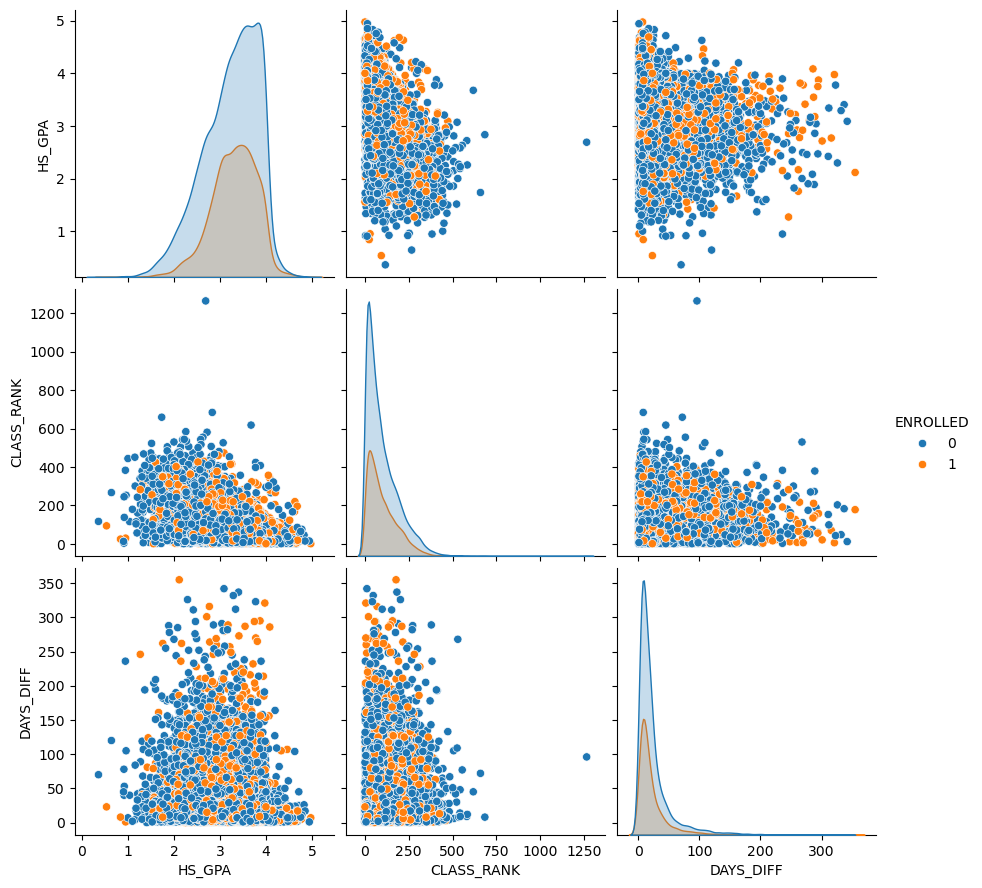

In [55]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns #Statistical Data Visualization
import matplotlib.pyplot as plt
%matplotlib inline
#pairplot
# Top four correlated inputs with survived
#df['Survived'] = df['Survived'].astype(str)  
attributes = ['HS_GPA','CLASS_RANK','DAYS_DIFF']
print("Admission Dataset: 0 for not enrolled and 1 for enrolled.")
sns.pairplot(data = Xy_train, hue="ENROLLED", vars = attributes, height=3)

Admission Dataset: 0 for not enrolled and 1 for enrolled.


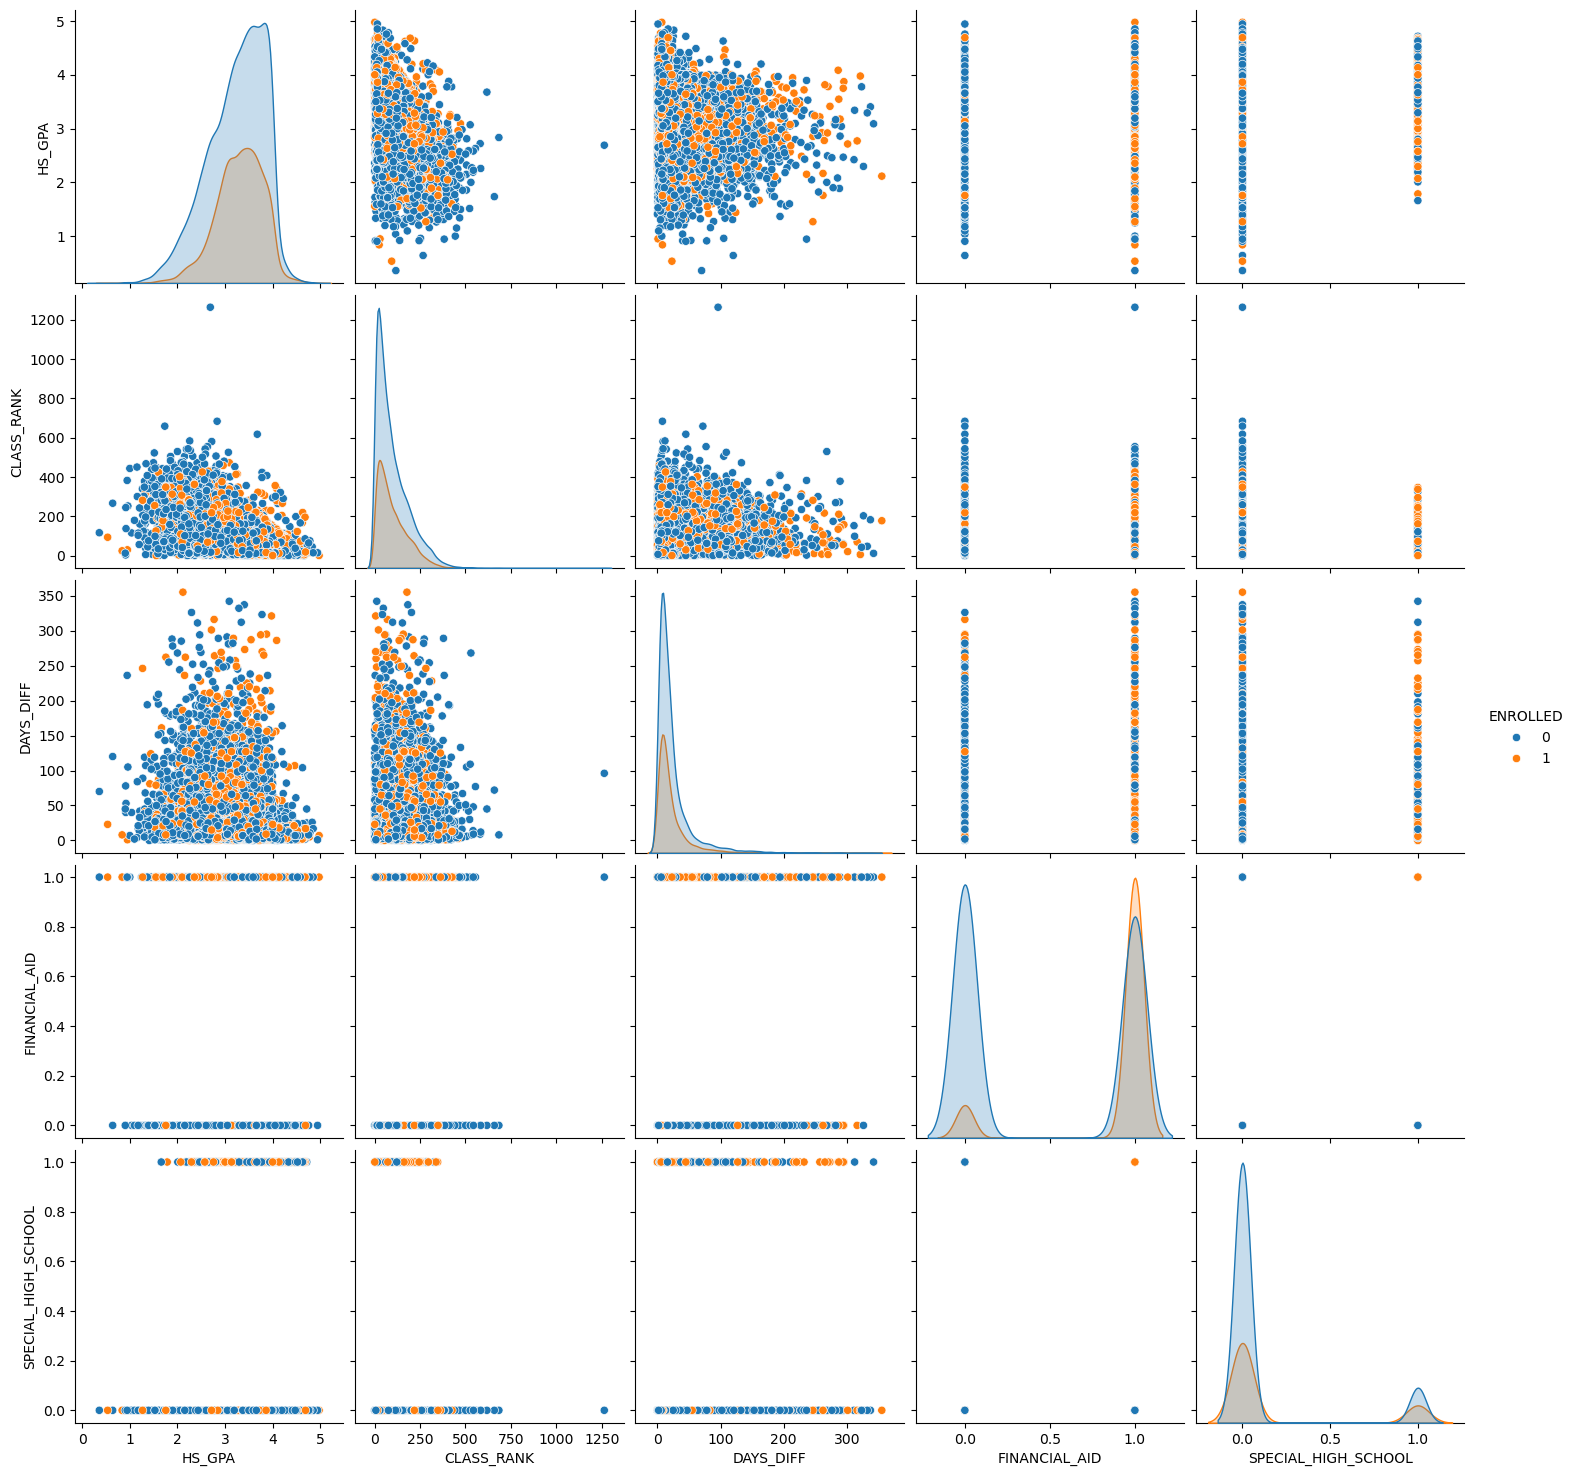

In [56]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

# Attributes to plot
attributes = ['HS_GPA','CLASS_RANK','DAYS_DIFF', 'FINANCIAL_AID', 'SPECIAL_HIGH_SCHOOL']

print("Admission Dataset: 0 for not enrolled and 1 for enrolled.")

# Pairplot
sns.pairplot(data=Xy_train, hue="ENROLLED", vars=attributes, height=3)

plt.show()  # ✅ This ensures the plot is displayed

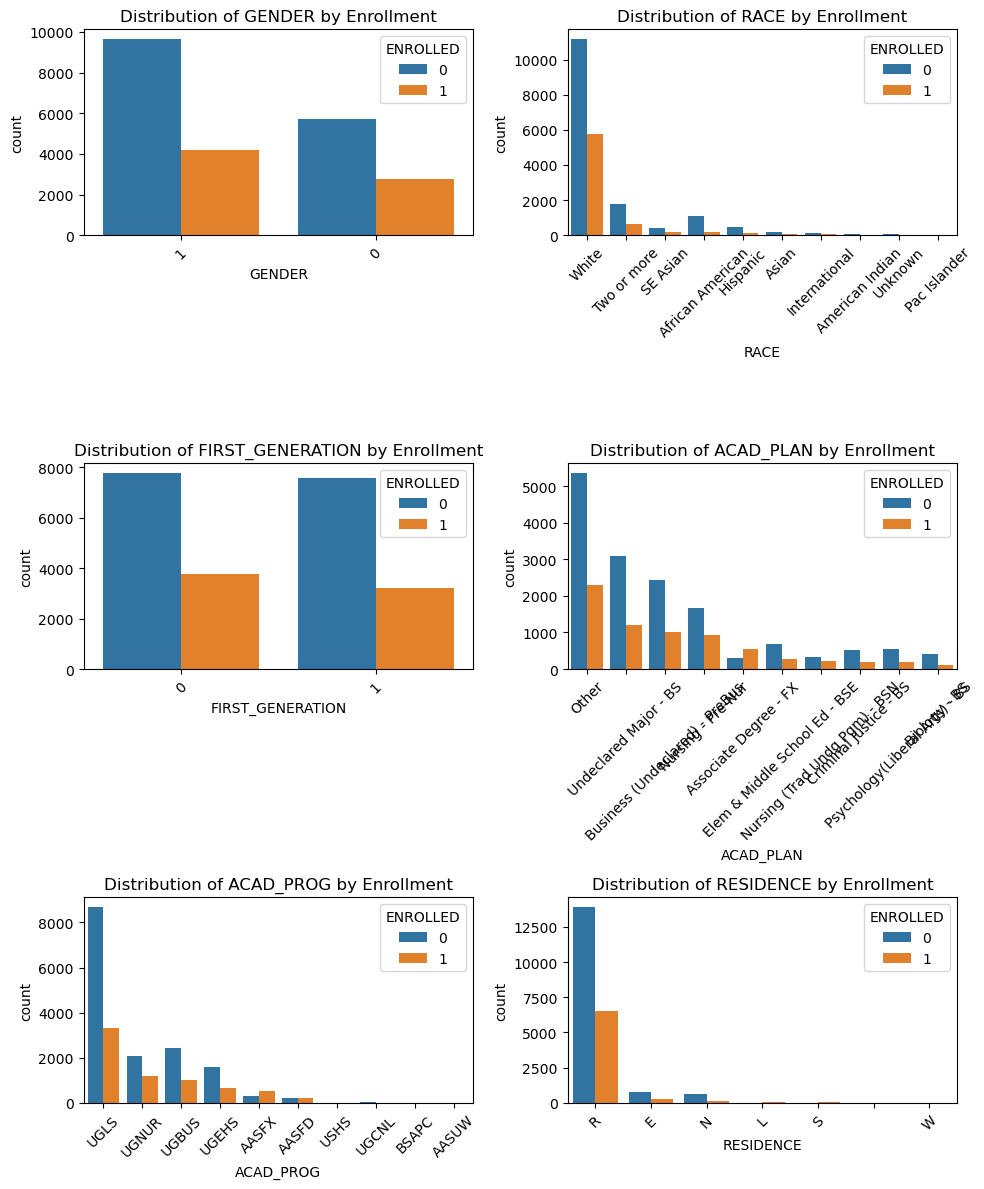

In [58]:
import matplotlib.pyplot as plt
import seaborn as sns

# Handle ACAD_PLAN with too many categories by limiting to top 10 and grouping others as 'Other'
top_10_plans = Xy_train['ACAD_PLAN'].value_counts().nlargest(10).index
Xy_train['ACAD_PLAN'] = Xy_train['ACAD_PLAN'].apply(lambda x: x if x in top_10_plans else 'Other')

# Define categorical variables
cat_vars = ['GENDER', 'RACE', 'FIRST_GENERATION', 'ACAD_PLAN', 'ACAD_PROG', 'RESIDENCE',]

# Layout: 2 charts per row
cols = 2
rows = (len(cat_vars) + cols - 1) // cols

plt.figure(figsize=(10, 4 * rows))

for idx, cat in enumerate(cat_vars):
    # Sort categories by enrolled_flag = 1 count
    order = (
        Xy_train[Xy_train['ENROLLED'] == 1][cat]
        .value_counts()
        .sort_values(ascending=False)
        .index
    )

    plt.subplot(rows, cols, idx + 1)
    sns.countplot(x=cat, data=Xy_train, hue="ENROLLED", order=order)
    plt.title(f"Distribution of {cat} by Enrollment")
    plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig('categorical_distribution_sorted.png')
plt.show()

## Logistic Regression Model

In [59]:
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.compose import ColumnTransformer, make_column_transformer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.impute import SimpleImputer

import numpy as np
import pandas as pd
from time import time

data = pd.read_csv('admissionML.csv')

fields = [
    "DAYS_DIFF",
    "ACAD_PROG",
    "ACAD_PLAN",
    "ENROLLED",
    "RACE",
    "GENDER",
    "ZIPCODE",
    "HS_GPA",
    "CLASS_RANK",
    "FIRST_GENERATION",
    "FINANCIAL_AID",
    "PARENT_INCOME",
    "SPECIAL_HIGH_SCHOOL",
    "RESIDENCE"
]
data = data[fields].copy()

# --- Target ---
y = data['ENROLLED']
X = data.drop(columns=['ENROLLED'])

# --- Split (stratified is recommended) ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42, stratify=y
)
X_train, X_valid, y_train, y_valid = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42, stratify=y_train
)

print(f"X train           shape: {X_train.shape}")
print(f"X validation      shape: {X_valid.shape}")
print(f"X test            shape: {X_test.shape}")

# --- Determine feature types ---
numerical_features = list(X.select_dtypes(include=['int64', 'float64']).columns)
categorical_features = list(X.select_dtypes(include=['object', 'bool']).columns)

# Treat these binary columns as categorical
binary_as_categorical = ['FINANCIAL_AID', 'SPECIAL_HIGH_SCHOOL', "PARENT_INCOME", "GENDER", "FIRST_GENERATION" ]

# Remove them from numerical_features if present
numerical_features = [col for col in numerical_features if col not in binary_as_categorical]

# Add them to categorical_features (if present in X)
categorical_features += [col for col in binary_as_categorical if col in X.columns]

# Remove overlap & duplicates to avoid mismatch
overlap = set(numerical_features) & set(categorical_features)
if overlap:
    numerical_features = [c for c in numerical_features if c not in overlap]

categorical_features = list(dict.fromkeys(categorical_features))  # dedupe while preserving order

print(f"numerical_features are  : {numerical_features}")
print(f"categorical_features are: {categorical_features}")

# --- Preprocessing pipelines ---
data_pipeline = make_column_transformer(
    (make_pipeline(SimpleImputer(strategy='median'), StandardScaler()), numerical_features),
    (make_pipeline(SimpleImputer(strategy='most_frequent'),
                   OneHotEncoder(handle_unknown='ignore')), categorical_features)
)

# --- Fit-transform training data ---
X_train_transformed = data_pipeline.fit_transform(X_train)
print(type(X_train_transformed))

# --- Robust feature-name extraction ---
# Preferred: ask ColumnTransformer directly (sklearn >= 1.0)
try:
    column_names = data_pipeline.get_feature_names_out()
except AttributeError:
    # Fallback: derive from fitted steps
    num_cols_used = data_pipeline.transformers_[0][2]  # numeric columns actually used
    ohe = data_pipeline.transformers_[1][1].named_steps['onehotencoder']
    # Call without args to use the encoder’s feature_names_in_ (avoids length mismatch)
    ohe_feature_names = ohe.get_feature_names_out()
    column_names = list(num_cols_used) + list(ohe_feature_names)

print(f"# feature names: {len(column_names)}")

# Convert to dense only for display
X_train_dense = X_train_transformed.toarray() if hasattr(X_train_transformed, 'toarray') else X_train_transformed
print(f"Transformed shape: {X_train_dense.shape}")

preview_df = pd.DataFrame(X_train_dense, columns=column_names)
print(preview_df.head())

number_of_inputs = X_train_transformed.shape[1]

# --- Classifier pipeline ---
clf_pipe = make_pipeline(
    data_pipeline,
    LogisticRegression(max_iter=1000, solver='liblinear')  # more robust convergence
)

# --- Train & evaluate ---
start = time()
clf_pipe.fit(X_train, y_train)
train_time = np.round(time() - start, 4)

trainAcc  = clf_pipe.score(X_train, y_train)
validAcc  = clf_pipe.score(X_valid, y_valid)
start = time()
testAcc   = clf_pipe.score(X_test, y_test)
test_time = np.round(time() - start, 4)

# --- Log results ---
expected_cols = ["Pipeline", "Dataset", "TrainAcc", "ValidAcc", "TestAcc",
                 "Train Time(s)", "Test Time(s)", "Description"]

if 'experimentLog' not in locals() or list(getattr(experimentLog, 'columns', [])) != expected_cols:
    experimentLog = pd.DataFrame(columns=expected_cols)

experimentLog.loc[len(experimentLog)] = {
    "Pipeline": f"Baseline 1 LogReg with {number_of_inputs} inputs",
    "Dataset": "Admission",
    "TrainAcc": f"{trainAcc*100:.2f}%",
    "ValidAcc": f"{validAcc*100:.2f}%",
    "TestAcc": f"{testAcc*100:.2f}%",
    "Train Time(s)": train_time,
    "Test Time(s)": test_time,
    "Description": "Baseline 1 LogReg pipeline with Cat+Num features"
}

print(experimentLog.tail(1))


X train           shape: (22339, 13)
X validation      shape: (5585, 13)
X test            shape: (4928, 13)
numerical_features are  : ['DAYS_DIFF', 'HS_GPA', 'CLASS_RANK']
categorical_features are: ['ACAD_PROG', 'ACAD_PLAN', 'RACE', 'ZIPCODE', 'RESIDENCE', 'FINANCIAL_AID', 'SPECIAL_HIGH_SCHOOL', 'PARENT_INCOME', 'GENDER', 'FIRST_GENERATION']
<class 'scipy.sparse._csr.csr_matrix'>
# feature names: 1561
Transformed shape: (22339, 1561)
   pipeline-1__DAYS_DIFF  pipeline-1__HS_GPA  pipeline-1__CLASS_RANK  \
0               3.390693           -0.682108                1.406523   
1              -0.669450           -0.030073               -0.582705   
2              -0.342019            0.182509               -0.617809   
3              -0.440249            0.550507               -0.840135   
4              -0.014588           -1.948666                0.025765   

   pipeline-2__ACAD_PROG_AASFD  pipeline-2__ACAD_PROG_AASFX  \
0                          0.0                          0.0   
1 

In [1]:
from sklearn.pipeline import Pipeline, FeatureUnion, make_pipeline
from sklearn.compose import ColumnTransformer
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer, make_column_transformer
from sklearn.model_selection import train_test_split  # sklearn.cross_validation in old versions
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.impute import SimpleImputer
from time import time

data = pd.read_csv('admissionML.csv')

fields = [
    "DAYS_DIFF",
    "ACAD_PROG",
    "ACAD_PLAN",
    "ENROLLED",
    "RACE",
    "GENDER",
    "ZIPCODE",
    "HS_GPA",
    "CLASS_RANK",
    "FIRST_GENERATION",
    "FINANCIAL_AID",
    "PARENT_INCOME",
    "SPECIAL_HIGH_SCHOOL",
    "RESIDENCE"
]
data = data[fields].copy()

# --- Target ---
y = data['ENROLLED']
X = data.drop(columns=['ENROLLED'])

X['ZIPCODE'] = X['ZIPCODE'].astype(str)
X['ZIPCODE'].dtype
# Split the provided training data into training and validationa and test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.15, random_state=42)
X_train, X_valid, y_train, y_valid = train_test_split(X_train, y_train, test_size=0.2, random_state=42)
print(f"X train           shape: {X_train.shape}")
print(f"X validation      shape: {X_valid.shape}")
print(f"X test            shape: {X_test.shape}")

# determine categorical and numerical features


# determine categorical and numerical features
numerical_features = list(X.select_dtypes(include=['int64', 'float64']).columns)
categorical_features = list(X.select_dtypes(include=['object', 'bool']).columns)

# Treat these binary columns as categorical
binary_as_categorical = ['FINANCIAL_AID', 'SPECIAL_HIGH_SCHOOL', "PARENT_INCOME", "GENDER", "FIRST_GENERATION",   ]

# Remove them from numerical_features if present
numerical_features = [col for col in numerical_features if col not in binary_as_categorical]

# Add them to categorical_features and then REMOVE DUPLICATES
categorical_features += [col for col in binary_as_categorical if col in X.columns]
categorical_features = list(dict.fromkeys(categorical_features))  # <- de-duplicate while preserving order

print(f"numerical_features are  : {numerical_features}")
print(f"categorical_features are: {categorical_features}")


data_pipeline = make_column_transformer( #Level 2
    (make_pipeline(SimpleImputer(), StandardScaler()),      numerical_features), #level 3
    (make_pipeline(SimpleImputer(strategy='most_frequent'), 
                   OneHotEncoder(handle_unknown='ignore')), categorical_features)  
  )
X_train_transformed = data_pipeline.fit_transform(X_train)
print(type(X_train_transformed))

column_names = numerical_features + list(
    data_pipeline.transformers_[1][1].named_steps["onehotencoder"].get_feature_names_out(categorical_features)
)

print(column_names)

X_train_dense = X_train_transformed.toarray()  # Convert sparse to dense
display(pd.DataFrame(X_train_dense, columns=column_names).head())
number_of_inputs = X_train_transformed.shape[1]

# Now we can combine this preprocessing step based on the ColumnTransformer with a
# classifier in a Pipeline to predict whether passengers of the Titanic survived or not:
clf_pipe = make_pipeline( #level 1
    data_pipeline,
    LogisticRegression())

# Time and score test predictions
start = time()
clf_pipe.fit(X_train, y_train)
train_time = np.round(time() - start, 4)

trainAcc  = clf_pipe.score(X_train, y_train)
validAcc  = clf_pipe.score(X_valid, y_valid)
start = time()
testAcc  = clf_pipe.score(X_test, y_test)
test_time = np.round(time() - start, 4)

#del experimentLog
try: experimentLog 
except : experimentLog = pd.DataFrame(columns=["Pipeline", "Dataset", "TrainAcc", "ValidAcc", "TestAcc",
                                               "Train Time(s)",  "Test Time(s)", "Description",])
experimentLog.loc[len(experimentLog)] =[f"Baseline 1 LogReg with {number_of_inputs} inputs", "Admission", 
                                        f"{trainAcc*100:8.2f}%", f"{validAcc*100:8.2f}%", f"{testAcc*100:8.2f}%",
                                        train_time, test_time,
                                        "Baseline 1 LogReg pipeline with Cat+Num features"]

experimentLog

X train           shape: (22339, 13)
X validation      shape: (5585, 13)
X test            shape: (4928, 13)
numerical_features are  : ['DAYS_DIFF', 'HS_GPA', 'CLASS_RANK']
categorical_features are: ['ACAD_PROG', 'ACAD_PLAN', 'RACE', 'ZIPCODE', 'RESIDENCE', 'FINANCIAL_AID', 'SPECIAL_HIGH_SCHOOL', 'PARENT_INCOME', 'GENDER', 'FIRST_GENERATION']
<class 'scipy.sparse._csr.csr_matrix'>
['DAYS_DIFF', 'HS_GPA', 'CLASS_RANK', 'ACAD_PROG_AASFD', 'ACAD_PROG_AASFX', 'ACAD_PROG_AASUW', 'ACAD_PROG_BSAPC', 'ACAD_PROG_UGBUS', 'ACAD_PROG_UGCNL', 'ACAD_PROG_UGEHS', 'ACAD_PROG_UGLS', 'ACAD_PROG_UGNUR', 'ACAD_PROG_UGUND', 'ACAD_PROG_USCNL', 'ACAD_PROG_USHS', 'ACAD_PLAN_Accounting - BBA', 'ACAD_PLAN_Advertising-BA', 'ACAD_PLAN_Anthropology - BA', 'ACAD_PLAN_Anthropology - BS', 'ACAD_PLAN_Applied Computing - BS', 'ACAD_PLAN_Art (Studio Art) - BS', 'ACAD_PLAN_Art History - BA', 'ACAD_PLAN_Art Major - BA', 'ACAD_PLAN_Art Undecided (BA)', 'ACAD_PLAN_Associate Degree', 'ACAD_PLAN_Associate Degree - FDL', 'ACAD

,DAYS_DIFF,HS_GPA,CLASS_RANK,ACAD_PROG_AASFD,ACAD_PROG_AASFX,ACAD_PROG_AASUW,ACAD_PROG_BSAPC,ACAD_PROG_UGBUS,ACAD_PROG_UGCNL,ACAD_PROG_UGEHS,...,FINANCIAL_AID_0,FINANCIAL_AID_1,SPECIAL_HIGH_SCHOOL_0,SPECIAL_HIGH_SCHOOL_1,PARENT_INCOME_0,PARENT_INCOME_1,GENDER_0,GENDER_1,FIRST_GENERATION_0,FIRST_GENERATION_1
0,-0.341520,1.288898,-1.093901,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,1.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,0.0
1,-0.111104,-1.007179,0.397698,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0
2,-0.473187,0.718422,-0.192004,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0
3,0.283896,-1.763680,1.530850,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,1.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0
4,0.053479,-0.768004,0.108628,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,1.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0


C:\Users\huynhd\AppData\Local\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,Pipeline,Dataset,TrainAcc,ValidAcc,TestAcc,Train Time(s),Test Time(s),Description
0,Baseline 1 LogReg with 1551 inputs,Admission,75.20%,71.71%,72.87%,0.4211,0.032,Baseline 1 LogReg pipeline with Cat+Num features


In [2]:
from sklearn.inspection import permutation_importance
import pandas as pd

perm = permutation_importance(
    clf_pipe, 
    X_valid, 
    y_valid,
    n_repeats=10,
    scoring="accuracy"       # or "precision"
)

perm_df = pd.DataFrame({
    "feature": X_valid.columns,
    "importance_mean": perm.importances_mean,
    "importance_std": perm.importances_std
}).sort_values("importance_mean", ascending=False)

print("Permutation importance (accuracy drop):")
display(perm_df)


Permutation importance (accuracy drop):


,feature,importance_mean,importance_std
9,FINANCIAL_AID,0.041038,0.003767
5,ZIPCODE,0.017708,0.004342
2,ACAD_PLAN,0.011996,0.002459
1,ACAD_PROG,0.009060,0.002838
7,CLASS_RANK,0.004136,0.000935
10,PARENT_INCOME,0.000895,0.001922
12,RESIDENCE,0.000716,0.001053
11,SPECIAL_HIGH_SCHOOL,0.000340,0.001272
6,HS_GPA,0.000304,0.001161
0,DAYS_DIFF,0.000107,0.000360


In [3]:
import numpy as np
import pandas as pd

pre = clf_pipe.named_steps['columntransformer']
logreg = clf_pipe.named_steps['logisticregression']

# Build feature names in the exact order produced by the fitted ColumnTransformer
expanded_feature_names = []
base_feature_names = []

for name, trans, cols in pre.transformers_:
    if name == 'remainder':
        # If you had remainder='passthrough', you would need to handle raw columns here
        continue
    
    cols = list(cols) if isinstance(cols, (list, tuple, np.ndarray, pd.Index)) else [cols]
    
    if hasattr(trans, "named_steps") and "onehotencoder" in trans.named_steps:
        ohe = trans.named_steps["onehotencoder"]
        # IMPORTANT: use the *same* cols that the fitted transformer used (not the global variable)
        ohe_feature_names = list(ohe.get_feature_names_out(cols))
        expanded_feature_names.extend(ohe_feature_names)
        # Map each expanded column back to its base categorical column
        for col, cats in zip(cols, ohe.categories_):
            base_feature_names.extend([col] * len(cats))
    else:
        # Pipelines like SimpleImputer+StandardScaler do not change #columns
        expanded_feature_names.extend(cols)
        base_feature_names.extend(cols)

# Sanity checks: these must match the model's coefficient vector length
n_model_features = logreg.coef_.shape[1]
assert len(expanded_feature_names) == n_model_features, \
    f"Feature name length ({len(expanded_feature_names)}) != coef length ({n_model_features})"
assert len(base_feature_names) == n_model_features, \
    "Base feature name vector length mismatch."

# Create coefficient table (binary classification → single row of coefs)
coefs = logreg.coef_.ravel()
odds = np.exp(coefs)

coef_df = (pd.DataFrame({
    "feature": expanded_feature_names,
    "base_feature": base_feature_names,
    "coef": coefs,
    "odds_ratio": odds,
    "abs_coef": np.abs(coefs)
})
.sort_values("abs_coef", ascending=False)
.reset_index(drop=True))

print("Top drivers by absolute coefficient (corrected mapping):")
display(coef_df.head(25))
print("Intercept (log-odds baseline):", float(logreg.intercept_[0]))

# Group back to original features: max |coef| across categories for a cleaner one-line summary
grouped_importance = (coef_df
    .groupby("base_feature")["abs_coef"]
    .max()
    .sort_values(ascending=False)
    .rename("group_importance_abscoef")
    .reset_index())

print("Grouped importance (max |coef| per original feature) — corrected:")
display(grouped_importance)

Top drivers by absolute coefficient (corrected mapping):


,feature,base_feature,coef,odds_ratio,abs_coef
0,ZIPCODE_53204,ZIPCODE,-2.227278,0.107822,2.227278
1,ZIPCODE_53215,ZIPCODE,-1.601114,0.201672,1.601114
2,ZIPCODE_54446,ZIPCODE,1.448161,4.255280,1.448161
3,ZIPCODE_54822,ZIPCODE,-1.441210,0.236641,1.441210
4,ZIPCODE_53205,ZIPCODE,-1.427116,0.240000,1.427116
5,ZIPCODE_54960,ZIPCODE,1.386881,4.002346,1.386881
6,RESIDENCE_S,RESIDENCE,1.355447,3.878496,1.355447
7,ZIPCODE_53108,ZIPCODE,1.322170,3.751552,1.322170
8,ACAD_PROG_USHS,ACAD_PROG,1.310508,3.708057,1.310508
9,ZIPCODE_53956,ZIPCODE,1.310431,3.707773,1.310431


Intercept (log-odds baseline): -0.3309487582622188
Grouped importance (max |coef| per original feature) — corrected:


,base_feature,group_importance_abscoef
0,ZIPCODE,2.227278
1,RESIDENCE,1.355447
2,ACAD_PROG,1.310508
3,ACAD_PLAN,1.224452
4,RACE,1.117374
5,FINANCIAL_AID,1.069035
6,PARENT_INCOME,0.231990
7,SPECIAL_HIGH_SCHOOL,0.147616
8,GENDER,0.143686
9,CLASS_RANK,0.126285


In [61]:
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.compose import ColumnTransformer, make_column_transformer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.impute import SimpleImputer
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.cluster import KMeans
from sklearn.feature_extraction.text import TfidfVectorizer

import numpy as np
import pandas as pd
from time import time

# -------------------------------
# 1) Custom transformers
# -------------------------------

class ZipCodeClusterer(BaseEstimator, TransformerMixin):
    """Cluster ZIP codes via KMeans and return cluster labels as a single column."""
    def __init__(self, n_clusters=10, random_state=42, n_init=10):
        self.n_clusters = n_clusters
        self.random_state = random_state
        self.n_init = n_init
        self.km_ = None

    def _to_numeric_zip(self, X):
        # X may come as shape (n_samples, 1) from ColumnTransformer
        s = pd.Series(np.array(X).ravel()).astype(str).str.extract(r'(\d+)')[0]
        z = pd.to_numeric(s, errors='coerce').fillna(-1).values.reshape(-1, 1)
        return z

    def fit(self, X, y=None):
        Z = self._to_numeric_zip(X)
        self.km_ = KMeans(n_clusters=self.n_clusters, random_state=self.random_state, n_init=self.n_init)
        self.km_.fit(Z)
        return self

    def transform(self, X):
        Z = self._to_numeric_zip(X)
        labels = self.km_.predict(Z)
        return labels.reshape(-1, 1)

    def get_feature_names_out(self, input_features=None):
        return np.array(['ZIP_CLUSTER'])


class AcadPlanClusterer(BaseEstimator, TransformerMixin):
    """Cluster ACAD_PLAN text using TF-IDF + KMeans and return cluster labels."""
    def __init__(self, n_clusters=5, random_state=42, n_init=10, stop_words='english', min_df=1):
        self.n_clusters = n_clusters
        self.random_state = random_state
        self.n_init = n_init
        self.stop_words = stop_words
        self.min_df = min_df
        self.vec_ = None
        self.km_ = None

    def _to_text(self, X):
        # X may come as shape (n_samples, 1); we convert to text
        texts = pd.Series(np.array(X).ravel()).fillna('').astype(str)
        return texts

    def fit(self, X, y=None):
        texts = self._to_text(X)
        self.vec_ = TfidfVectorizer(stop_words=self.stop_words, min_df=self.min_df)
        Xv = self.vec_.fit_transform(texts)
        self.km_ = KMeans(n_clusters=self.n_clusters, random_state=self.random_state, n_init=self.n_init)
        self.km_.fit(Xv)
        return self

    def transform(self, X):
        texts = self._to_text(X)
        Xv = self.vec_.transform(texts)
        labels = self.km_.predict(Xv)
        return labels.reshape(-1, 1)

    def get_feature_names_out(self, input_features=None):
        return np.array(['ACAD_PLAN_CLUSTER'])


# -------------------------------
# 2) Load & filter data
# -------------------------------
data = pd.read_csv('admissionML.csv')

fields = [
    "DAYS_DIFF",
    "ACAD_PROG",
    "ACAD_PLAN",
    "ENROLLED",
    "RACE",
    "GENDER",
    "ZIPCODE",
    "HS_GPA",
    "CLASS_RANK",
    "FIRST_GENERATION",
    "FINANCIAL_AID",
    "PARENT_INCOME",
    "SPECIAL_HIGH_SCHOOL",
    "RESIDENCE"
]
data = data[fields].copy()

# --- Target ---
y = data['ENROLLED']
X = data.drop(columns=['ENROLLED'])

# Optional: ensure ZIP is string (clusterer will clean it further)
X.loc[:, 'ZIPCODE'] = X['ZIPCODE'].astype(str)

# Split (stratify recommended)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.15, random_state=42, stratify=y)
X_train, X_valid, y_train, y_valid = train_test_split(X_train, y_train, test_size=0.2, random_state=42, stratify=y_train)

print(f"X train           shape: {X_train.shape}")
print(f"X validation      shape: {X_valid.shape}")
print(f"X test            shape: {X_test.shape}")

# -------------------------------
# 3) Feature groups
# -------------------------------
numerical_features = list(X.select_dtypes(include=['int64', 'float64']).columns)
categorical_features = list(X.select_dtypes(include=['object', 'bool']).columns)

# We will feed ACAD_PLAN & ZIPCODE through cluster pipelines (not the standard cat pipeline)
for col in ['ACAD_PLAN', 'ZIPCODE']:
    if col in categorical_features:
        categorical_features.remove(col)
    if col in numerical_features:
        numerical_features.remove(col)

# Binary flags as categorical
binary_as_categorical = ['FINANCIAL_AID', 'SPECIAL_HIGH_SCHOOL', "PARENT_INCOME", "GENDER", "FIRST_GENERATION",   ]
numerical_features = [c for c in numerical_features if c not in binary_as_categorical]
categorical_features += [c for c in binary_as_categorical if c in X.columns]
categorical_features = list(dict.fromkeys(categorical_features))  # dedupe

print(f"numerical_features are  : {numerical_features}")
print(f"categorical_features are: {categorical_features}")

# -------------------------------
# 4) ColumnTransformer with clustering branches
# -------------------------------
data_pipeline = ColumnTransformer(
    transformers=[
        # Numeric
        ('num', make_pipeline(SimpleImputer(strategy='median'), StandardScaler()), numerical_features),

        # Regular categoricals (excluding ZIPCODE & ACAD_PLAN)
        ('cat', make_pipeline(SimpleImputer(strategy='most_frequent'),
                              OneHotEncoder(handle_unknown='ignore')), categorical_features),

        # ZIP clustering -> labels -> OHE
        ('zip_cluster', make_pipeline(
            SimpleImputer(strategy='most_frequent'),     # if any missing ZIPs
            ZipCodeClusterer(n_clusters=10, random_state=42, n_init=10),
            OneHotEncoder(handle_unknown='ignore')       # treat cluster labels as categories
        ), ['ZIPCODE']),

        # ACAD_PLAN text clustering -> labels -> OHE
        ('plan_cluster', make_pipeline(
            SimpleImputer(strategy='most_frequent'),
            AcadPlanClusterer(n_clusters=5, random_state=42, n_init=10, stop_words='english', min_df=1),
            OneHotEncoder(handle_unknown='ignore')
        ), ['ACAD_PLAN']),
    ],
    remainder='drop'  # ignore unspecified columns
)

# -------------------------------
# 5) Fit-transform & inspect
# -------------------------------
X_train_transformed = data_pipeline.fit_transform(X_train)
print(type(X_train_transformed))

# Feature names (works in sklearn >= 1.0)
try:
    column_names = data_pipeline.get_feature_names_out()
except AttributeError:
    # Fallback if your sklearn is older: skip names or build manually
    column_names = [f'f{i}' for i in range(X_train_transformed.shape[1])]

print(f"# feature names: {len(column_names)}")
print(f"Transformed shape: {X_train_transformed.shape}")

# Display a preview (convert to dense if sparse)
X_train_dense = X_train_transformed.toarray() if hasattr(X_train_transformed, 'toarray') else X_train_transformed
preview_df = pd.DataFrame(X_train_dense[:, :min(10, X_train_dense.shape[1])], columns=list(column_names[:min(10, len(column_names))]))
print(preview_df.head())

number_of_inputs = X_train_transformed.shape[1]

# -------------------------------
# 6) Classifier pipeline
# -------------------------------
clf_pipe = make_pipeline(
    data_pipeline,
    LogisticRegression(max_iter=1000, solver='liblinear')  # robust convergence for OHE’d features
)

# -------------------------------
# 7) Train & evaluate
# -------------------------------
start = time()
clf_pipe.fit(X_train, y_train)
train_time = np.round(time() - start, 4)

trainAcc  = clf_pipe.score(X_train, y_train)
validAcc  = clf_pipe.score(X_valid, y_valid)
start = time()
testAcc   = clf_pipe.score(X_test, y_test)
test_time = np.round(time() - start, 4)

# -------------------------------
# 8) Log results
# -------------------------------
try:
    experimentLog
except NameError:
    experimentLog = pd.DataFrame(columns=["Pipeline", "Dataset", "TrainAcc", "ValidAcc", "TestAcc",
                                          "Train Time(s)", "Test Time(s)", "Description"])

experimentLog.loc[len(experimentLog)] = [
    f"Baseline LogReg with {number_of_inputs} inputs", "Admission FYR 800",
    f"{trainAcc*100:8.2f}%", f"{validAcc*100:8.2f}%", f"{testAcc*100:8.2f}%",
    train_time, test_time,
    "LogReg with Num + OHE Cat + ZIP/Plan clusters (no leakage)"
]

print(experimentLog.tail(1))


X train           shape: (22339, 13)
X validation      shape: (5585, 13)
X test            shape: (4928, 13)
numerical_features are  : ['DAYS_DIFF', 'HS_GPA', 'CLASS_RANK']
categorical_features are: ['ACAD_PROG', 'RACE', 'RESIDENCE', 'FINANCIAL_AID', 'SPECIAL_HIGH_SCHOOL', 'PARENT_INCOME', 'GENDER', 'FIRST_GENERATION']
<class 'scipy.sparse._csr.csr_matrix'>
# feature names: 56
Transformed shape: (22339, 56)
   num__DAYS_DIFF  num__HS_GPA  num__CLASS_RANK  cat__ACAD_PROG_AASFD  \
0        3.390693    -0.682108         1.406523                   0.0   
1       -0.669450    -0.030073        -0.582705                   0.0   
2       -0.342019     0.182509        -0.617809                   0.0   
3       -0.440249     0.550507        -0.840135                   0.0   
4       -0.014588    -1.948666         0.025765                   0.0   

   cat__ACAD_PROG_AASFX  cat__ACAD_PROG_AASUW  cat__ACAD_PROG_BSAPC  \
0                   0.0                   0.0                   0.0   
1       


=== Confusion Matrix (Test) ===
[[2941  444]
 [ 960  583]]

=== Classification Report (Test) ===
              precision    recall  f1-score   support

           0      0.754     0.869     0.807      3385
           1      0.568     0.378     0.454      1543

    accuracy                          0.715      4928
   macro avg      0.661     0.623     0.630      4928
weighted avg      0.696     0.715     0.697      4928

ROC-AUC (Test): 0.7745


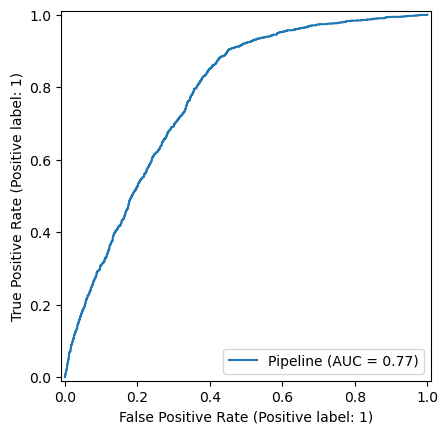


5-fold CV ROC-AUC: mean=0.7770, std=0.0074

=== Top 15 features by |coef| ===
cat__ACAD_PROG_USHS                                 coef= 1.5313
cat__RESIDENCE_S                                    coef= 1.4401
cat__RESIDENCE_N                                    coef=-1.3010
plan_cluster__ACAD_PLAN_CLUSTER_0                   coef= 1.1508
cat__FINANCIAL_AID_0                                coef=-1.0725
cat__FINANCIAL_AID_1                                coef= 0.9624
cat__RESIDENCE_E                                    coef=-0.7634
zip_cluster__ZIP_CLUSTER_0                          coef=-0.6238
cat__RACE_Pac Islander                              coef= 0.5917
zip_cluster__ZIP_CLUSTER_8                          coef=-0.5825
zip_cluster__ZIP_CLUSTER_7                          coef= 0.5792
plan_cluster__ACAD_PLAN_CLUSTER_3                   coef=-0.5540
cat__RACE_International                             coef= 0.5452
cat__RACE_African American                          coef=-0.5416
zip_cluster

In [62]:

from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, RocCurveDisplay
from sklearn.model_selection import StratifiedKFold, cross_val_score
import matplotlib.pyplot as plt
import numpy as np

# Predictions & probabilities
y_pred = clf_pipe.predict(X_test)
y_proba = clf_pipe.predict_proba(X_test)[:, 1] if hasattr(clf_pipe[-1], 'predict_proba') else None

print("\n=== Confusion Matrix (Test) ===")
print(confusion_matrix(y_test, y_pred))

print("\n=== Classification Report (Test) ===")
print(classification_report(y_test, y_pred, digits=3))

if y_proba is not None:
    roc = roc_auc_score(y_test, y_proba)
    print(f"ROC-AUC (Test): {roc:.4f}")
    RocCurveDisplay.from_estimator(clf_pipe, X_test, y_test)
    plt.show()

# Stratified CV ROC-AUC for robustness
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_auc = cross_val_score(clf_pipe, X, y, cv=cv, scoring='roc_auc')
print(f"\n5-fold CV ROC-AUC: mean={cv_auc.mean():.4f}, std={cv_auc.std():.4f}")

# Interpretability: feature names + coefficients
try:
    feature_names = clf_pipe[0].get_feature_names_out()
except AttributeError:
    feature_names = [f"f{i}" for i in range(clf_pipe[0].transform(X_train).shape[1])]

coefs = clf_pipe[-1].coef_.ravel()
top_idx = np.argsort(np.abs(coefs))[::-1][:15]
print("\n=== Top 15 features by |coef| ===")
for i in top_idx:
    print(f"{feature_names[i]:50s}  coef={coefs[i]: .4f}")


In [67]:
import numpy as np
from sklearn.metrics import precision_recall_curve, f1_score, confusion_matrix

# Get probabilities for class 1
y_proba = clf_pipe.predict_proba(X_test)[:, 1]

# Precision-Recall curve
prec, rec, thrs = precision_recall_curve(y_test, y_proba)

# Choose threshold by maximizing F1
f1s = (2 * prec * rec) / (prec + rec + 1e-12)
best_idx = np.argmax(f1s)
best_thr = thrs[best_idx] if best_idx < len(thrs) else 0.5

print(f"Best F1 threshold ≈ {best_thr:.3f} | F1={f1s[best_idx]:.3f} | P={prec[best_idx]:.3f} | R={rec[best_idx]:.3f}")

# Apply custom threshold
y_pred_thr = (y_proba >= best_thr).astype(int)
print("Confusion @ best F1 threshold:\n", confusion_matrix(y_test, y_pred_thr))


Best F1 threshold ≈ 0.290 | F1=0.623 | P=0.490 | R=0.854
Confusion @ best F1 threshold:
 [[2011 1374]
 [ 225 1319]]


In [68]:

from sklearn.calibration import CalibratedClassifierCV

calibrated_clf = make_pipeline(
    data_pipeline,
    CalibratedClassifierCV(LogisticRegression(max_iter=1000, solver='liblinear'),
                           method='isotonic', cv=5)
)

calibrated_clf.fit(X_train, y_train)
y_proba_cal = calibrated_clf.predict_proba(X_test)[:, 1]
print("Calibrated ROC-AUC:", roc_auc_score(y_test, y_proba_cal))


Calibrated ROC-AUC: 0.7780443284530196


## Logistic Regression Regular Admit 

In [3]:

import numpy as np
import pandas as pd
from time import time

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.compose import ColumnTransformer, make_column_transformer
from sklearn.pipeline import make_pipeline, Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score, f1_score, classification_report, confusion_matrix

# ---------------------------
# Load and filter once
# ---------------------------
data = pd.read_csv('admissionML.csv')

fields = [
    "DAYS_DIFF",
    "ACAD_PROG",
    "ACAD_PLAN",
    "ENROLLED",
    "RACE",
    "GENDER",
    "ZIPCODE",
    "HS_GPA",
    "CLASS_RANK",
    "FIRST_GENERATION",
    "FINANCIAL_AID",
    "PARENT_INCOME",
    "SPECIAL_HIGH_SCHOOL",
    "RESIDENCE"
]
data = data[fields].copy()

# --- Target ---
y = data['ENROLLED']
X = data.drop(columns=[ 'ENROLLED'])

# Clean ZIP to string
X.loc[:, 'ZIPCODE'] = X['ZIPCODE'].astype(str)

# Train/valid/test split (same for both models)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42, stratify=y
)
X_train, X_valid, y_train, y_valid = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42, stratify=y_train
)

# ---------------------------
# Helper: evaluate a pipeline
# ---------------------------
def evaluate_pipeline(name, pipe, X_train, y_train, X_valid, y_valid, X_test, y_test, X_all, y_all):
    start = time(); pipe.fit(X_train, y_train); train_time = np.round(time() - start, 4)

    # Accuracy
    train_acc = pipe.score(X_train, y_train)
    valid_acc = pipe.score(X_valid, y_valid)
    start = time(); test_acc = pipe.score(X_test, y_test); test_time = np.round(time() - start, 4)

    # Probabilities & metrics
    y_proba = pipe.predict_proba(X_test)[:, 1]
    y_pred  = (y_proba >= 0.5).astype(int)

    roc = roc_auc_score(y_test, y_proba)
    f1  = f1_score(y_test, y_pred)

    # 5-fold CV ROC-AUC on all data
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    cv_auc = cross_val_score(pipe, X_all, y_all, cv=cv, scoring='roc_auc')

    print(f"\n[{name}] TrainAcc={train_acc:.4f} ValidAcc={valid_acc:.4f} TestAcc={test_acc:.4f} ROC-AUC={roc:.4f} F1={f1:.4f}")
    print("CV ROC-AUC: mean={:.4f}, std={:.4f}".format(cv_auc.mean(), cv_auc.std()))
    print("Confusion (Test):\n", confusion_matrix(y_test, y_pred))
    print("Classification Report (Test):\n", classification_report(y_test, y_pred, digits=3))

    return {
        "Pipeline": name,
        "TrainAcc": train_acc,
        "ValidAcc": valid_acc,
        "TestAcc": test_acc,
        "ROC-AUC": roc,
        "F1": f1,
        "Train Time(s)": train_time,
        "Test Time(s)": test_time,
        "CV AUC mean": cv_auc.mean(),
        "CV AUC std": cv_auc.std()
    }

# ---------------------------
# Model A: OHE-only (no clustering)
# ---------------------------
num_feats = list(X.select_dtypes(include=['int64','float64']).columns)
cat_feats = list(X.select_dtypes(include=['object','bool']).columns)

# Force binary to categorical
binary_as_cat = ['FINANCIAL_AID', 'SPECIAL_HIGH_SCHOOL', "PARENT_INCOME", "GENDER", "FIRST_GENERATION",   ]
num_feats = [c for c in num_feats if c not in binary_as_cat]
cat_feats += [c for c in binary_as_cat if c in X.columns]
cat_feats = list(dict.fromkeys(cat_feats))

pipe_ohe = make_pipeline(
    make_column_transformer(
        (make_pipeline(SimpleImputer(strategy='median'), StandardScaler()), num_feats),
        (make_pipeline(SimpleImputer(strategy='most_frequent'),
                       OneHotEncoder(handle_unknown='ignore', drop='first')), cat_feats)
    ),
    LogisticRegression(max_iter=1000, solver='liblinear')
)

# ---------------------------
# Model B: ZIP/ACAD_PLAN clustered branches
# ---------------------------
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.cluster import KMeans
from sklearn.feature_extraction.text import TfidfVectorizer

class ZipCodeClusterer(BaseEstimator, TransformerMixin):
    def __init__(self, n_clusters=10, random_state=42, n_init=10):
        self.n_clusters = n_clusters; self.random_state = random_state; self.n_init = n_init
    def fit(self, X, y=None):
        s = pd.Series(np.array(X).ravel()).astype(str).str.extract(r'(\d+)')[0]
        z = pd.to_numeric(s, errors='coerce').fillna(-1).values.reshape(-1,1)
        self.km_ = KMeans(n_clusters=self.n_clusters, random_state=self.random_state, n_init=self.n_init).fit(z)
        return self
    def transform(self, X):
        s = pd.Series(np.array(X).ravel()).astype(str).str.extract(r'(\d+)')[0]
        z = pd.to_numeric(s, errors='coerce').fillna(-1).values.reshape(-1,1)
        return self.km_.predict(z).reshape(-1,1)

class AcadPlanClusterer(BaseEstimator, TransformerMixin):
    def __init__(self, n_clusters=5, random_state=42, n_init=10, stop_words='english', min_df=1):
        self.n_clusters=n_clusters; self.random_state=random_state; self.n_init=n_init
        self.stop_words=stop_words; self.min_df=min_df
    def fit(self, X, y=None):
        texts = pd.Series(np.array(X).ravel()).fillna('').astype(str)
        self.vec_ = TfidfVectorizer(stop_words=self.stop_words, min_df=self.min_df)
        Xv = self.vec_.fit_transform(texts)
        self.km_ = KMeans(n_clusters=self.n_clusters, random_state=self.random_state, n_init=self.n_init).fit(Xv)
        return self
    def transform(self, X):
        texts = pd.Series(np.array(X).ravel()).fillna('').astype(str)
        Xv = self.vec_.transform(texts)
        return self.km_.predict(Xv).reshape(-1,1)

# Remove ZIPCODE and ACAD_PLAN from normal cat list (they’re handled by cluster branches)
num_feats_B  = list(X.select_dtypes(include=['int64','float64']).columns)
cat_feats_B  = list(X.select_dtypes(include=['object','bool']).columns)
for col in ['ACAD_PLAN', 'ZIPCODE']:
    if col in num_feats_B: num_feats_B.remove(col)
    if col in cat_feats_B: cat_feats_B.remove(col)
num_feats_B = [c for c in num_feats_B if c not in binary_as_cat]
cat_feats_B += [c for c in binary_as_cat if c in X.columns]
cat_feats_B = list(dict.fromkeys(cat_feats_B))

pipe_cluster = make_pipeline(
    ColumnTransformer(
        transformers=[
            ('num', make_pipeline(SimpleImputer(strategy='median'), StandardScaler()), num_feats_B),
            ('cat', make_pipeline(SimpleImputer(strategy='most_frequent'),
                                  OneHotEncoder(handle_unknown='ignore', drop='first')), cat_feats_B),
            ('zip_cluster', make_pipeline(SimpleImputer(strategy='most_frequent'),
                                          ZipCodeClusterer(n_clusters=10, random_state=42, n_init=10),
                                          OneHotEncoder(handle_unknown='ignore', drop='first')), ['ZIPCODE']),
            ('plan_cluster', make_pipeline(SimpleImputer(strategy='most_frequent'),
                                           AcadPlanClusterer(n_clusters=5, random_state=42, n_init=10),
                                           OneHotEncoder(handle_unknown='ignore', drop='first')), ['ACAD_PLAN']),
        ],
        remainder='drop'
    ),
    LogisticRegression(max_iter=1000, solver='liblinear')
)

# ---------------------------
# Evaluate both on same split
# ---------------------------
results_A = evaluate_pipeline("OHE-only (523 inputs?)", pipe_ohe,
                              X_train, y_train, X_valid, y_valid, X_test, y_test,
                              X, y)

results_B = evaluate_pipeline("Clustered (ZIP+Plan, ~46 inputs)", pipe_cluster,
                              X_train, y_train, X_valid, y_valid, X_test, y_test,
                              X, y)

# ---------------------------
# Summary table and ranking
# ---------------------------
summary = pd.DataFrame([results_A, results_B])
summary['TestAcc%'] = (summary['TestAcc'] * 100).round(2)
summary['ROC-AUC%'] = (summary['ROC-AUC'] * 100).round(2)
summary['F1%']      = (summary['F1'] * 100).round(2)

print("\n=== Comparison Summary (sorted by ROC-AUC then F1) ===")
print(summary.sort_values(by=['ROC-AUC','F1'], ascending=False)[[
    'Pipeline','TestAcc%','ROC-AUC%','F1%','Train Time(s)','Test Time(s)','CV AUC mean','CV AUC std'
]])


C:\Users\huynhd\AppData\Local\anaconda3\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [0, 1, 3] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
C:\Users\huynhd\AppData\Local\anaconda3\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [1, 3] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
C:\Users\huynhd\AppData\Local\anaconda3\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [1, 3] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
C:\Users\huynhd\AppData\Local\anaconda3\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [1, 3] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
C:\Users\huynhd\AppData\L


[OHE-only (523 inputs?)] TrainAcc=0.7539 ValidAcc=0.7262 TestAcc=0.7165 ROC-AUC=0.7798 F1=0.4862
CV ROC-AUC: mean=0.7846, std=0.0053
Confusion (Test):
 [[2870  515]
 [ 882  661]]
Classification Report (Test):
               precision    recall  f1-score   support

           0      0.765     0.848     0.804      3385
           1      0.562     0.428     0.486      1543

    accuracy                          0.717      4928
   macro avg      0.664     0.638     0.645      4928
weighted avg      0.701     0.717     0.705      4928



C:\Users\huynhd\AppData\Local\anaconda3\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
C:\Users\huynhd\AppData\Local\anaconda3\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
C:\Users\huynhd\AppData\Local\anaconda3\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
C:\Users\huynhd\AppData\Local\anaconda3\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(



[Clustered (ZIP+Plan, ~46 inputs)] TrainAcc=0.7217 ValidAcc=0.7232 TestAcc=0.7153 ROC-AUC=0.7742 F1=0.4534
CV ROC-AUC: mean=0.7769, std=0.0073
Confusion (Test):
 [[2943  442]
 [ 961  582]]
Classification Report (Test):
               precision    recall  f1-score   support

           0      0.754     0.869     0.808      3385
           1      0.568     0.377     0.453      1543

    accuracy                          0.715      4928
   macro avg      0.661     0.623     0.630      4928
weighted avg      0.696     0.715     0.697      4928


=== Comparison Summary (sorted by ROC-AUC then F1) ===
                           Pipeline  TestAcc%  ROC-AUC%    F1%  Train Time(s)  \
0            OHE-only (523 inputs?)     71.65     77.98  48.62         0.4569   
1  Clustered (ZIP+Plan, ~46 inputs)     71.53     77.42  45.34         3.4996   

   Test Time(s)  CV AUC mean  CV AUC std  
0        0.0599     0.784570    0.005252  
1        0.0871     0.776904    0.007323  


In [4]:
from sklearn.inspection import permutation_importance
import pandas as pd

perm = permutation_importance(
    clf_pipe, 
    X_valid, 
    y_valid,
    n_repeats=10,
    scoring="accuracy"       # or "precision"
)

perm_df = pd.DataFrame({
    "feature": X_valid.columns,
    "importance_mean": perm.importances_mean,
    "importance_std": perm.importances_std
}).sort_values("importance_mean", ascending=False)

print("Permutation importance (accuracy drop):")
display(perm_df)


Permutation importance (accuracy drop):


,feature,importance_mean,importance_std
9,FINANCIAL_AID,0.045927,0.004071
5,ZIPCODE,0.030134,0.003504
2,ACAD_PLAN,0.014503,0.002495
1,ACAD_PROG,0.013500,0.003254
12,RESIDENCE,0.004727,0.001659
10,PARENT_INCOME,0.003778,0.002738
3,RACE,0.003098,0.002685
7,CLASS_RANK,0.000143,0.002930
8,FIRST_GENERATION,0.000054,0.001276
0,DAYS_DIFF,-0.000215,0.000193


In [9]:
from sklearn.inspection import permutation_importance
import pandas as pd

perm = permutation_importance(
    clf_pipe, 
    X_valid, 
    y_valid,
    n_repeats=10,
    scoring="precision"       # or "precision"
)

perm_df = pd.DataFrame({
    "feature": X_valid.columns,
    "importance_mean": perm.importances_mean,
    "importance_std": perm.importances_std
}).sort_values("importance_mean", ascending=False)

print("Permutation importance (accuracy drop):")
display(perm_df)


Permutation importance (accuracy drop):


,feature,importance_mean,importance_std
9,FINANCIAL_AID,0.088754,0.006224
5,ZIPCODE,0.061503,0.005658
2,ACAD_PLAN,0.031104,0.004553
1,ACAD_PROG,0.028973,0.003216
11,SPECIAL_HIGH_SCHOOL,0.004806,0.002303
7,CLASS_RANK,0.004624,0.003763
12,RESIDENCE,0.003378,0.002878
6,HS_GPA,0.002341,0.002356
0,DAYS_DIFF,0.000318,0.000291
4,GENDER,0.000000,0.000000


In [43]:
if 'experimentLog' in locals():
    experimentLog = experimentLog.iloc[0:0]  # Clears all rows but keeps columns

## LGBM Model

In [10]:
# TRAIN & SAVE LightGBM (DIRECT_ADMIT == 'N', ADMIT_TERM=800)
import numpy as np
import pandas as pd
from time import time
import joblib, json
import lightgbm as lgb

from lightgbm import LGBMClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import (
    accuracy_score, roc_auc_score, f1_score,
    classification_report, confusion_matrix, precision_recall_curve
)
from pandas.api.types import CategoricalDtype
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline

# -----------------------------
# 0) Configuration
# -----------------------------
RANDOM_STATE = 42

# Fields (pre-enrollment only)
FIELDS = [
    "DAYS_DIFF","ACAD_PROG","ACAD_PLAN","RACE","GENDER","ZIPCODE",
    "HS_GPA","CLASS_RANK","FIRST_GENERATION","FINANCIAL_AID", "PARENT_INCOME",
    "SPECIAL_HIGH_SCHOOL","RESIDENCE"
]

NUMERIC_COLS = ["DAYS_DIFF", "HS_GPA", "CLASS_RANK"]
CAT_COLS = [
    "ACAD_PROG","ACAD_PLAN","RACE","GENDER","ZIPCODE",
    "FIRST_GENERATION","RESIDENCE","FINANCIAL_AID","SPECIAL_HIGH_SCHOOL", "PARENT_INCOME"
]

# -----------------------------
# Helper: cast to categorical with UNK safely
# -----------------------------
def cast_with_categories(df, col, categories):
    """
    Cast df[col] to categorical with provided categories.
    Ensures strings are stripped and missing/unseen -> 'UNK'.
    Avoids using .cat.add_categories unless necessary.
    """
    # normalize to string prior to category casting
    s = df[col].astype(str).str.strip()

    # guarantee 'UNK' is present in categories
    cats = categories
    if "UNK" not in cats:
        cats = ["UNK"] + list(cats)

    dtype = CategoricalDtype(categories=cats)
    s = s.astype(dtype)

    # If any value isn’t in cats, it becomes NaN; replace with 'UNK'.
    # Note: fillna works on categorical series.
    s = s.fillna("UNK")
    df[col] = s
    return df

# -----------------------------
# 1) Load & filter Fall 2025 (800), DIRECT=N
# -----------------------------
df_800_N = pd.read_csv("admissionMLS.csv")

y = df_800_N["ENROLLED"].astype(int)

X = df_800_N[FIELDS].copy()

# ZIP: preserve leading zeros & whitespace before any categorical casting
X.loc[:, "ZIPCODE"] = X["ZIPCODE"].astype(str).str.strip().str.zfill(5)

# Ensure numerics are truly numeric (coerce bad values to NaN)
for c in NUMERIC_COLS:
    X.loc[:, c] = pd.to_numeric(X[c], errors="coerce")

# -----------------------------
# 3) Stratified splits
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.15, random_state=RANDOM_STATE, stratify=y
)
X_train, X_valid, y_train, y_valid = train_test_split(
    X_train, y_train, test_size=0.2, random_state=RANDOM_STATE, stratify=y_train
)

# -----------------------------
# 4) Lock training categories & apply to valid/test
# -----------------------------
cat_dtype_map = {}
for c in CAT_COLS:
    # categories from training only (strings)
    train_cats = sorted(X_train[c].astype(str).dropna().unique())
    # prepend UNK
    cats = ["UNK"] + train_cats
    cat_dtype_map[c] = cats

    # cast each split; avoid .cat.add_categories unless missing
    X_train = cast_with_categories(X_train, c, cats)
    X_valid = cast_with_categories(X_valid, c, cats)
    X_test  = cast_with_categories(X_test,  c, cats)

# -----------------------------
# 5) LightGBM classifier
# -----------------------------
lgbm = LGBMClassifier(
    objective="binary",
    boosting_type="gbdt",
    n_estimators=1000,
    learning_rate=0.05,
    num_leaves=31,
    max_depth=-1,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    class_weight="balanced",   # helpful for minority class
    random_state=RANDOM_STATE,
    n_jobs=-1,
    categorical_feature=CAT_COLS
)

# -----------------------------
# 6) Fit with callbacks (early stopping)
# -----------------------------
start = time()
lgbm.fit(
    X_train, y_train,
    eval_set=[(X_valid, y_valid)],
    eval_metric="auc",
    callbacks=[
        lgb.early_stopping(stopping_rounds=50),
        lgb.log_evaluation(period=50)
    ]
)
train_time = np.round(time() - start, 4)

# -----------------------------
# 7) Evaluate on TEST
# -----------------------------
y_proba = lgbm.predict_proba(X_test)[:, 1]
y_pred  = (y_proba >= 0.50).astype(int)

acc = accuracy_score(y_test, y_pred)
roc = roc_auc_score(y_test, y_proba)
f1  = f1_score(y_test, y_pred)

print(f"TestAcc={acc:.4f} ROC-AUC={roc:.4f} F1={f1:.4f}")
print("Confusion:\n", confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred, digits=3))

# Threshold tuning (best F1 on TEST)
prec, rec, thrs = precision_recall_curve(y_test, y_proba)
f1s = (2 * prec * rec) / (prec + rec + 1e-12)
best_idx = int(np.argmax(f1s))
best_thr = thrs[best_idx] if best_idx < len(thrs) else 0.5
print(f"Best F1 threshold ≈ {best_thr:.3f} | F1={f1s[best_idx]:.4f} | P={prec[best_idx]:.4f} | R={rec[best_idx]:.4f}")

# -----------------------------
# 8) Robust CV with per-fold category locking (no leakage)
# -----------------------------
class ToNumeric(BaseEstimator, TransformerMixin):
    """Coerce specified columns to numeric (errors->NaN)."""
    def __init__(self, cols):
        self.cols = cols
    def fit(self, X, y=None):
        return self
    def transform(self, X):
        X = X.copy()
        for c in self.cols:
            X[c] = pd.to_numeric(X[c], errors="coerce")
        return X

class ToCategory(BaseEstimator, TransformerMixin):
    """Make specified columns categorical with categories learned from the training fold."""
    def __init__(self, cat_cols, add_unk=True):
        self.cat_cols = cat_cols
        self.add_unk = add_unk
        self.categories_ = {}

    def fit(self, X, y=None):
        X = X.copy()
        for c in self.cat_cols:
            cats = sorted(X[c].astype(str).dropna().unique())
            if self.add_unk and "UNK" not in cats:
                cats = ["UNK"] + cats
            self.categories_[c] = cats
        return self

    def transform(self, X):
        X = X.copy()
        # preserve ZIP leading zeros before categorization
        if "ZIPCODE" in self.cat_cols and "ZIPCODE" in X.columns:
            X["ZIPCODE"] = X["ZIPCODE"].astype(str).str.strip().str.zfill(5)
        for c in self.cat_cols:
            cats = self.categories_[c]
            dtype = CategoricalDtype(categories=cats)
            s = X[c].astype(str).str.strip().astype(dtype)
            # fill NaN (unseen/missing) with UNK (safe; s is categorical already)
            s = s.fillna("UNK")
            X[c] = s
        return X

pipe = Pipeline(steps=[
    ("to_numeric", ToNumeric(NUMERIC_COLS)),
    ("to_category", ToCategory(CAT_COLS, add_unk=True)),
    ("clf", LGBMClassifier(
        objective="binary",
        boosting_type="gbdt",
        n_estimators=1000,
        learning_rate=0.05,
        num_leaves=31,
        max_depth=-1,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_lambda=1.0,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1,
        categorical_feature=CAT_COLS
    ))
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_auc = cross_val_score(pipe, X, y, cv=cv, scoring="roc_auc")
print(f"5-fold CV ROC-AUC: mean={cv_auc.mean():.4f}, std={cv_auc.std():.4f}")

# -----------------------------
# 9) Save model & metadata
# -----------------------------
joblib.dump(lgbm, "directN_lgbm_model.joblib")

metadata = {
    "cohort": "DIRECT_ADMIT == 'N' | ADMIT_TERM=800",
    "fields": FIELDS,
    "numerical_features": NUMERIC_COLS,
    "categorical_features": CAT_COLS,
    "cat_categories": cat_dtype_map,      # dict of {feature: [training categories incl. UNK]}
    "best_threshold_from_800_test": float(best_thr),
    "train_time_sec": float(train_time),
    "params": {
        "objective": "binary", "n_estimators": 1000, "learning_rate": 0.05,
        "num_leaves": 31, "subsample": 0.8, "colsample_bytree": 0.8,
        "reg_lambda": 1.0, "class_weight": "balanced", "random_state": RANDOM_STATE
    },
    "metrics_test": {
        "accuracy": float(acc),
        "roc_auc": float(roc),
        "f1": float(f1),
        "best_threshold_f1": float(best_thr),
        "precision_at_best": float(prec[best_idx]),
        "recall_at_best": float(rec[best_idx]),
    },
    "cv_auc": {
        "mean": float(cv_auc.mean()),
        "std": float(cv_auc.std())
    }
}
with open("directN_lgbm_metadata.json", "w") as f:
    json.dump(metadata, f, indent=2)

print("\n✅ Saved: directN_lgbm_model.joblib and directN_lgbm_metadata.json")

C:\Users\huynhd\AppData\Local\Temp\ipykernel_24104\3951697957.py:72: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '['29072' '55033' '55033' ... '69337' '80124' '95376']' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  X.loc[:, "ZIPCODE"] = X["ZIPCODE"].astype(str).str.strip().str.zfill(5)
C:\Users\huynhd\AppData\Roaming\Python\Python313\site-packages\lightgbm\basic.py:2137: UserWarning: categorical_feature keyword has been found in `params` and will be ignored.
Please use categorical_feature argument of the Dataset constructor to pass this parameter.
  _log_warning(
C:\Users\huynhd\AppData\Roaming\Python\Python313\site-packages\lightgbm\basic.py:2159: UserWarning: categorical_feature in param dict is overridden.
  _log_warning(f"{cat_alias} in param dict is overridden.")
C:\Users\huynhd\AppData\Roaming\Python\Python313\site-packages\lightgbm\basic.py:2137: UserWarning: categ

[LightGBM] [Warning] Categorical features with more bins than the configured maximum bin number found.
[LightGBM] [Warning] For categorical features, max_bin and max_bin_by_feature may be ignored with a large number of categories.
[LightGBM] [Warning] categorical_feature is set=ACAD_PROG,ACAD_PLAN,RACE,GENDER,ZIPCODE,FIRST_GENERATION,RESIDENCE,FINANCIAL_AID,SPECIAL_HIGH_SCHOOL,PARENT_INCOME, categorical_column=1,2,3,4,5,8,9,10,11,12 will be ignored. Current value: categorical_feature=ACAD_PROG,ACAD_PLAN,RACE,GENDER,ZIPCODE,FIRST_GENERATION,RESIDENCE,FINANCIAL_AID,SPECIAL_HIGH_SCHOOL,PARENT_INCOME
[LightGBM] [Info] Number of positive: 6993, number of negative: 15336
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000688 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1590
[LightGBM] [Info] Number of data points in the train set: 22329, n

C:\Users\huynhd\AppData\Roaming\Python\Python313\site-packages\lightgbm\basic.py:2137: UserWarning: categorical_feature keyword has been found in `params` and will be ignored.
Please use categorical_feature argument of the Dataset constructor to pass this parameter.
  _log_warning(
C:\Users\huynhd\AppData\Roaming\Python\Python313\site-packages\lightgbm\basic.py:2159: UserWarning: categorical_feature in param dict is overridden.
  _log_warning(f"{cat_alias} in param dict is overridden.")


[LightGBM] [Warning] Categorical features with more bins than the configured maximum bin number found.
[LightGBM] [Warning] For categorical features, max_bin and max_bin_by_feature may be ignored with a large number of categories.
[LightGBM] [Warning] categorical_feature is set=ACAD_PROG,ACAD_PLAN,RACE,GENDER,ZIPCODE,FIRST_GENERATION,RESIDENCE,FINANCIAL_AID,SPECIAL_HIGH_SCHOOL,PARENT_INCOME, categorical_column=1,2,3,4,5,8,9,10,11,12 will be ignored. Current value: categorical_feature=ACAD_PROG,ACAD_PLAN,RACE,GENDER,ZIPCODE,FIRST_GENERATION,RESIDENCE,FINANCIAL_AID,SPECIAL_HIGH_SCHOOL,PARENT_INCOME
[LightGBM] [Info] Number of positive: 8227, number of negative: 18043
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002607 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1657
[LightGBM] [Info] Number of data points in the train set: 26270, n

C:\Users\huynhd\AppData\Roaming\Python\Python313\site-packages\lightgbm\basic.py:2137: UserWarning: categorical_feature keyword has been found in `params` and will be ignored.
Please use categorical_feature argument of the Dataset constructor to pass this parameter.
  _log_warning(
C:\Users\huynhd\AppData\Roaming\Python\Python313\site-packages\lightgbm\basic.py:2159: UserWarning: categorical_feature in param dict is overridden.
  _log_warning(f"{cat_alias} in param dict is overridden.")


...

[LightGBM] [Warning] Categorical features with more bins than the configured maximum bin number found.
[LightGBM] [Warning] For categorical features, max_bin and max_bin_by_feature may be ignored with a large number of categories.
[LightGBM] [Warning] categorical_feature is set=ACAD_PROG,ACAD_PLAN,RACE,GENDER,ZIPCODE,FIRST_GENERATION,RESIDENCE,FINANCIAL_AID,SPECIAL_HIGH_SCHOOL,PARENT_INCOME, categorical_column=1,2,3,4,5,8,9,10,11,12 will be ignored. Current value: categorical_feature=ACAD_PROG,ACAD_PLAN,RACE,GENDER,ZIPCODE,FIRST_GENERATION,RESIDENCE,FINANCIAL_AID,SPECIAL_HIGH_SCHOOL,PARENT_INCOME
[LightGBM] [Info] Number of positive: 8227, number of negative: 18043
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001446 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1659
[LightGBM] [Info] Number of data points in the train set: 26270, number of used features: 13
[LightGBM] [Info] [binary:BoostFromSc

C:\Users\huynhd\AppData\Roaming\Python\Python313\site-packages\lightgbm\basic.py:2137: UserWarning: categorical_feature keyword has been found in `params` and will be ignored.
Please use categorical_feature argument of the Dataset constructor to pass this parameter.
  _log_warning(
C:\Users\huynhd\AppData\Roaming\Python\Python313\site-packages\lightgbm\basic.py:2159: UserWarning: categorical_feature in param dict is overridden.
  _log_warning(f"{cat_alias} in param dict is overridden.")


[LightGBM] [Warning] Categorical features with more bins than the configured maximum bin number found.
[LightGBM] [Warning] For categorical features, max_bin and max_bin_by_feature may be ignored with a large number of categories.
[LightGBM] [Warning] categorical_feature is set=ACAD_PROG,ACAD_PLAN,RACE,GENDER,ZIPCODE,FIRST_GENERATION,RESIDENCE,FINANCIAL_AID,SPECIAL_HIGH_SCHOOL,PARENT_INCOME, categorical_column=1,2,3,4,5,8,9,10,11,12 will be ignored. Current value: categorical_feature=ACAD_PROG,ACAD_PLAN,RACE,GENDER,ZIPCODE,FIRST_GENERATION,RESIDENCE,FINANCIAL_AID,SPECIAL_HIGH_SCHOOL,PARENT_INCOME
[LightGBM] [Info] Number of positive: 8227, number of negative: 18044
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001297 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1653
[LightGBM] [Info] Number of data points in the train set: 26271, n

C:\Users\huynhd\AppData\Roaming\Python\Python313\site-packages\lightgbm\basic.py:2137: UserWarning: categorical_feature keyword has been found in `params` and will be ignored.
Please use categorical_feature argument of the Dataset constructor to pass this parameter.
  _log_warning(
C:\Users\huynhd\AppData\Roaming\Python\Python313\site-packages\lightgbm\basic.py:2159: UserWarning: categorical_feature in param dict is overridden.
  _log_warning(f"{cat_alias} in param dict is overridden.")


[LightGBM] [Warning] Categorical features with more bins than the configured maximum bin number found.
[LightGBM] [Warning] For categorical features, max_bin and max_bin_by_feature may be ignored with a large number of categories.
[LightGBM] [Warning] categorical_feature is set=ACAD_PROG,ACAD_PLAN,RACE,GENDER,ZIPCODE,FIRST_GENERATION,RESIDENCE,FINANCIAL_AID,SPECIAL_HIGH_SCHOOL,PARENT_INCOME, categorical_column=1,2,3,4,5,8,9,10,11,12 will be ignored. Current value: categorical_feature=ACAD_PROG,ACAD_PLAN,RACE,GENDER,ZIPCODE,FIRST_GENERATION,RESIDENCE,FINANCIAL_AID,SPECIAL_HIGH_SCHOOL,PARENT_INCOME
[LightGBM] [Info] Number of positive: 8228, number of negative: 18043
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001652 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1656
[LightGBM] [Info] Number of data points in the train set: 26271, n

In [11]:
from sklearn.inspection import permutation_importance
import pandas as pd

metrics = ["accuracy", "precision", "recall", "f1"]
results = {}

for metric in metrics:
    perm = permutation_importance(
        clf_pipe,
        X_valid,
        y_valid,
        n_repeats=10,
        random_state=42,
        scoring=metric
    )

    df = pd.DataFrame({
        "feature": X_valid.columns,
        f"{metric}_drop_mean": perm.importances_mean,
        f"{metric}_drop_std": perm.importances_std
    }).sort_values(f"{metric}_drop_mean", ascending=False)

    results[metric] = df


In [12]:
for metric in metrics:
    print(f"\nPermutation importance for {metric.upper()}:")
    display(results[metric])


Permutation importance for ACCURACY:


,feature,accuracy_drop_mean,accuracy_drop_std
2,ACAD_PLAN,0.016891,0.002042
5,ZIPCODE,0.013720,0.001724
1,ACAD_PROG,0.013004,0.002165
12,RESIDENCE,0.002221,0.000773
3,RACE,0.001182,0.000773
6,HS_GPA,0.000376,0.000753
4,GENDER,0.000000,0.000000
8,FIRST_GENERATION,0.000000,0.000000
9,FINANCIAL_AID,0.000000,0.000000
10,PARENT_INCOME,0.000000,0.000000



Permutation importance for PRECISION:


,feature,precision_drop_mean,precision_drop_std
2,ACAD_PLAN,0.112933,0.010638
1,ACAD_PROG,0.092880,0.011600
5,ZIPCODE,0.088891,0.011750
12,RESIDENCE,0.014907,0.005290
3,RACE,0.005393,0.005147
6,HS_GPA,0.001765,0.005209
7,CLASS_RANK,0.001446,0.008337
4,GENDER,0.000000,0.000000
8,FIRST_GENERATION,0.000000,0.000000
9,FINANCIAL_AID,0.000000,0.000000



Permutation importance for RECALL:


,feature,recall_drop_mean,recall_drop_std
5,ZIPCODE,0.027632,0.004312
3,RACE,0.004405,0.002111
12,RESIDENCE,0.003204,0.001642
6,HS_GPA,0.001316,0.001228
4,GENDER,0.000000,0.000000
8,FIRST_GENERATION,0.000000,0.000000
9,FINANCIAL_AID,0.000000,0.000000
10,PARENT_INCOME,0.000000,0.000000
11,SPECIAL_HIGH_SCHOOL,0.000000,0.000000
0,DAYS_DIFF,-0.000172,0.000515



Permutation importance for F1:


,feature,f1_drop_mean,f1_drop_std
5,ZIPCODE,0.042658,0.006309
2,ACAD_PLAN,0.006245,0.005202
3,RACE,0.006139,0.002963
12,RESIDENCE,0.005290,0.002367
6,HS_GPA,0.001842,0.001902
4,GENDER,0.000000,0.000000
8,FIRST_GENERATION,0.000000,0.000000
9,FINANCIAL_AID,0.000000,0.000000
10,PARENT_INCOME,0.000000,0.000000
11,SPECIAL_HIGH_SCHOOL,0.000000,0.000000


In [13]:
combined = results["accuracy"][["feature"]].copy()

for metric in metrics:
    combined = combined.merge(
        results[metric][["feature", f"{metric}_drop_mean"]],
        on="feature",
        how="left"
    )

display(combined.sort_values("accuracy_drop_mean", ascending=False))

,feature,accuracy_drop_mean,precision_drop_mean,recall_drop_mean,f1_drop_mean
0,ACAD_PLAN,0.016891,0.112933,-0.003261,0.006245
1,ZIPCODE,0.013720,0.088891,0.027632,0.042658
2,ACAD_PROG,0.013004,0.092880,-0.012300,-0.006546
3,RESIDENCE,0.002221,0.014907,0.003204,0.005290
4,RACE,0.001182,0.005393,0.004405,0.006139
5,HS_GPA,0.000376,0.001765,0.001316,0.001842
6,GENDER,0.000000,0.000000,0.000000,0.000000
7,FIRST_GENERATION,0.000000,0.000000,0.000000,0.000000
8,FINANCIAL_AID,0.000000,0.000000,0.000000,0.000000
9,PARENT_INCOME,0.000000,0.000000,0.000000,0.000000


In [6]:
from sklearn.inspection import permutation_importance
import pandas as pd

perm = permutation_importance(
    clf_pipe, 
    X_valid, 
    y_valid,
    n_repeats=10,
    scoring="accuracy"       # or "precision"
)

perm_df = pd.DataFrame({
    "feature": X_valid.columns,
    "importance_mean": perm.importances_mean,
    "importance_std": perm.importances_std
}).sort_values("importance_mean", ascending=False)

print("Permutation importance (accuracy drop):")
display(perm_df)


Permutation importance (accuracy drop):


,feature,importance_mean,importance_std
2,ACAD_PLAN,0.017052,0.004417
5,ZIPCODE,0.014025,0.001848
1,ACAD_PROG,0.013792,0.003114
12,RESIDENCE,0.001952,0.000509
3,RACE,0.000788,0.000627
6,HS_GPA,0.000734,0.000834
4,GENDER,0.000000,0.000000
8,FIRST_GENERATION,0.000000,0.000000
9,FINANCIAL_AID,0.000000,0.000000
10,PARENT_INCOME,0.000000,0.000000


## XGBoot Model

In [7]:

# TRAIN & SAVE XGBoost via native API (DIRECT_ADMIT == 'N', ADMIT_TERM=800)
import numpy as np
import pandas as pd
from time import time
import joblib, json

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import (
    accuracy_score, roc_auc_score, f1_score,
    classification_report, confusion_matrix, precision_recall_curve
)
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

import xgboost as xgb
from scipy import sparse

# -----------------------------
# 0) Configuration
# -----------------------------
RANDOM_STATE = 42

# FIELDS = [
#     "DAYS_DIFF","ACAD_PROG","ACAD_PLAN","RACE","SEX","ZIPCODE",
#     "HS_GPA","CLASS_RANK","FIRST_GENERATION","FINANCIAL_AID",
#     "SPECIAL_HIGH_SCHOOL","RESIDENCE"
# ]
# NUMERIC_COLS = ["DAYS_DIFF", "HS_GPA", "CLASS_RANK"]
# CAT_COLS = [
#     "ACAD_PROG","ACAD_PLAN","RACE","SEX","ZIPCODE",
#     "FIRST_GENERATION","RESIDENCE","FINANCIAL_AID","SPECIAL_HIGH_SCHOOL" 
# ]

FIELDS = [
    "DAYS_DIFF","ACAD_PROG","ACAD_PLAN","RACE","GENDER","ZIPCODE",
    "HS_GPA","CLASS_RANK","FIRST_GENERATION","FINANCIAL_AID", "PARENT_INCOME",
    "SPECIAL_HIGH_SCHOOL","RESIDENCE"
]

NUMERIC_COLS = ["DAYS_DIFF", "HS_GPA", "CLASS_RANK"]
CAT_COLS = [
    "ACAD_PROG","ACAD_PLAN","RACE","GENDER","ZIPCODE",
    "FIRST_GENERATION","RESIDENCE","FINANCIAL_AID","SPECIAL_HIGH_SCHOOL", "PARENT_INCOME"
]

# -----------------------------
# 1) Load & filter Fall 2025 (800), DIRECT=N
# -----------------------------
df_800_N = pd.read_csv("admissionMLS.csv")

y = df_800_N["ENROLLED"].astype(int)

X = df_800_N[FIELDS].copy()

# ZIP: preserve leading zeros
X.loc[:, "ZIPCODE"] = X["ZIPCODE"].astype(str).str.strip().str.zfill(5)

# Numerics: coerce bad values to NaN
for c in NUMERIC_COLS:
    X.loc[:, c] = pd.to_numeric(X[c], errors="coerce")

# -----------------------------
# 3) Stratified splits
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.15, random_state=RANDOM_STATE, stratify=y
)
X_train, X_valid, y_train, y_valid = train_test_split(
    X_train, y_train, test_size=0.2, random_state=RANDOM_STATE, stratify=y_train
)

# -----------------------------
# 4) Preprocessor (fit on TRAIN only)
# -----------------------------
# OneHotEncoder learns categories on training set; ignore unseen at inference.
ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=True, dtype=np.float32)
preprocessor = ColumnTransformer(
    transformers=[
        ("num", "passthrough", NUMERIC_COLS),
        ("cat", ohe, CAT_COLS),
    ],
    remainder="drop",
    sparse_threshold=1.0
)

# Fit preprocessor on training, then transform all splits
X_train_t = preprocessor.fit_transform(X_train)
X_valid_t = preprocessor.transform(X_valid)
X_test_t  = preprocessor.transform(X_test)

# Ensure CSR (DMatrix accepts dense or CSR/CSC)
def to_csr(m):
    return m.tocsr() if sparse.issparse(m) else sparse.csr_matrix(m)

X_train_t = to_csr(X_train_t)
X_valid_t = to_csr(X_valid_t)
X_test_t  = to_csr(X_test_t)

# -----------------------------
# 5) XGBoost params & DMatrix
# -----------------------------
pos = int(y_train.sum())
neg = int(len(y_train) - pos)
scale_pos_weight = (neg / pos) if pos > 0 else 1.0

params = {
    "objective": "binary:logistic",
    "eval_metric": "auc",
    "eta": 0.05,             # == learning_rate
    "max_depth": 6,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "lambda": 1.0,           # L2 (reg_lambda)
    "gamma": 0.0,
    "min_child_weight": 1.0,
    "scale_pos_weight": scale_pos_weight,
    "tree_method": "hist",   # use "gpu_hist" if GPU available
    "seed": RANDOM_STATE,
    "nthread": -1
}

dtrain = xgb.DMatrix(X_train_t, label=y_train)
dvalid = xgb.DMatrix(X_valid_t, label=y_valid)
dtest  = xgb.DMatrix(X_test_t,  label=y_test)

# -----------------------------
# 6) Train with early stopping
# -----------------------------
num_boost_round = 1000
start = time()
bst = xgb.train(
    params,
    dtrain,
    num_boost_round=num_boost_round,
    evals=[(dvalid, "valid")],
    early_stopping_rounds=50,
    verbose_eval=50
)
train_time = np.round(time() - start, 4)

# Best iteration utility (compat across versions)
best_iter = getattr(bst, "best_iteration", None)
best_ntree_limit = getattr(bst, "best_ntree_limit", None)

def predict_proba_booster(booster, dmatrix):
    if best_ntree_limit is not None:
        return booster.predict(dmatrix, ntree_limit=best_ntree_limit)
    elif best_iter is not None:
        return booster.predict(dmatrix, iteration_range=(0, best_iter + 1))
    else:
        return booster.predict(dmatrix)

# -----------------------------
# 7) Evaluate on TEST
# -----------------------------
y_proba = predict_proba_booster(bst, dtest)
y_pred  = (y_proba >= 0.50).astype(int)

acc = accuracy_score(y_test, y_pred)
roc = roc_auc_score(y_test, y_proba)
f1  = f1_score(y_test, y_pred)

print(f"[XGB] Train time={train_time:.2f}s | TestAcc={acc:.4f} ROC-AUC={roc:.4f} F1={f1:.4f}")
print("Confusion:\n", confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred, digits=3))

# Threshold tuning (best F1 on TEST)
prec, rec, thrs = precision_recall_curve(y_test, y_proba)
f1s = (2 * prec * rec) / (prec + rec + 1e-12)
best_idx = int(np.argmax(f1s))
best_thr = thrs[best_idx] if best_idx < len(thrs) else 0.5
print(f"Best F1 threshold ≈ {best_thr:.3f} | F1={f1s[best_idx]:.4f} | P={prec[best_idx]:.4f} | R={rec[best_idx]:.4f}")

# -----------------------------
# 8) 5-fold CV with per-fold category locking (no leakage)
# -----------------------------
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_aucs = []

for fold_idx, (tr_idx, va_idx) in enumerate(cv.split(X, y), start=1):
    X_tr, X_va = X.iloc[tr_idx], X.iloc[va_idx]
    y_tr, y_va = y.iloc[tr_idx], y.iloc[va_idx]

    # Fit encoder on training fold only
    fold_ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=True, dtype=np.float32)
    fold_pre = ColumnTransformer(
        transformers=[("num", "passthrough", NUMERIC_COLS), ("cat", fold_ohe, CAT_COLS)],
        remainder="drop",
        sparse_threshold=1.0
    )
    X_tr_t = to_csr(fold_pre.fit_transform(X_tr))
    X_va_t = to_csr(fold_pre.transform(X_va))

    dtr = xgb.DMatrix(X_tr_t, label=y_tr)
    dva = xgb.DMatrix(X_va_t, label=y_va)

    # For CV we typically fix num_boost_round (or use a small early stopping on a split of training fold)
    bst_cv = xgb.train(
        params,
        dtr,
        num_boost_round=300,        # lighter for CV
        verbose_eval=False
    )
    y_va_proba = bst_cv.predict(dva)
    cv_auc = roc_auc_score(y_va, y_va_proba)
    cv_aucs.append(cv_auc)
    print(f"[CV] Fold {fold_idx}: ROC-AUC={cv_auc:.4f}")

print(f"[XGB] 5-fold CV ROC-AUC: mean={np.mean(cv_aucs):.4f}, std={np.std(cv_aucs):.4f}")

# -----------------------------
# 9) Save inference pipeline (preprocessor + booster)
# -----------------------------
class XGBInferencePipeline:
    """Simple wrapper to bundle a fitted preprocessor and XGBoost Booster."""
    def __init__(self, preprocessor, booster, best_iter=None, best_ntree_limit=None):
        self.preprocessor = preprocessor
        self.booster = booster
        self.best_iter = best_iter
        self.best_ntree_limit = best_ntree_limit

    def _predict_proba_raw(self, X_df):
        X_t = self.preprocessor.transform(X_df)
        X_t = to_csr(X_t)
        dmat = xgb.DMatrix(X_t)
        if self.best_ntree_limit is not None:
            return self.booster.predict(dmat, ntree_limit=self.best_ntree_limit)
        elif self.best_iter is not None:
            return self.booster.predict(dmat, iteration_range=(0, self.best_iter + 1))
        else:
            return self.booster.predict(dmat)

    def predict_proba(self, X_df):
        p = self._predict_proba_raw(X_df)
        # Return sklearn-like shape: (n_samples, 2)
        return np.vstack([1.0 - p, p]).T

    def predict(self, X_df, threshold=0.5):
        p = self._predict_proba_raw(X_df)
        return (p >= threshold).astype(int)

# Bundle and save
inference = XGBInferencePipeline(preprocessor, bst, best_iter, best_ntree_limit)
joblib.dump(inference, "xgb_enrollment_model.joblib")

meta = {
    "model_type": "xgb.train(Booster)",
    "random_state": RANDOM_STATE,
    "train_time_sec": float(train_time),
    "features": FIELDS,
    "numeric_cols": NUMERIC_COLS,
    "categorical_cols": CAT_COLS,
    "scale_pos_weight": float(scale_pos_weight),
    "test_metrics": {
        "accuracy": float(acc),
        "roc_auc": float(roc),
        "f1": float(f1),
        "best_f1_threshold": float(best_thr),
        "best_f1_precision": float(prec[best_idx]),
        "best_f1_recall": float(rec[best_idx])
    }
}
with open("xgb_enrollment_meta.json", "w") as f:
    json.dump(meta, f, indent=2)
print("Saved xgb_enrollment_model.joblib and xgb_enrollment_meta.json")


C:\Users\huynhd\AppData\Local\Temp\ipykernel_24104\2502430420.py:56: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '['29072' '55033' '55033' ... '69337' '80124' '95376']' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  X.loc[:, "ZIPCODE"] = X["ZIPCODE"].astype(str).str.strip().str.zfill(5)


[0]	valid-auc:0.76303
[50]	valid-auc:0.78783
[100]	valid-auc:0.79090
[150]	valid-auc:0.79352
[200]	valid-auc:0.79471
[250]	valid-auc:0.79592
[300]	valid-auc:0.79624
[350]	valid-auc:0.79661
[400]	valid-auc:0.79740
[450]	valid-auc:0.79793
[496]	valid-auc:0.79786
[XGB] Train time=1.47s | TestAcc=0.6965 ROC-AUC=0.7994 F1=0.6319
Confusion:
 [[2148 1235]
 [ 260 1283]]
              precision    recall  f1-score   support

           0      0.892     0.635     0.742      3383
           1      0.510     0.831     0.632      1543

    accuracy                          0.697      4926
   macro avg      0.701     0.733     0.687      4926
weighted avg      0.772     0.697     0.707      4926

Best F1 threshold ≈ 0.506 | F1=0.6343 | P=0.5132 | R=0.8302
[CV] Fold 1: ROC-AUC=0.7913
[CV] Fold 2: ROC-AUC=0.7967
[CV] Fold 3: ROC-AUC=0.7945
[CV] Fold 4: ROC-AUC=0.7943
[CV] Fold 5: ROC-AUC=0.7924
[XGB] 5-fold CV ROC-AUC: mean=0.7938, std=0.0019
Saved xgb_enrollment_model.joblib and xgb_enrollment_meta.j

In [8]:
from sklearn.inspection import permutation_importance
import pandas as pd

perm = permutation_importance(
    clf_pipe, 
    X_valid, 
    y_valid,
    n_repeats=10,
    scoring="accuracy"       # or "precision"
)

perm_df = pd.DataFrame({
    "feature": X_valid.columns,
    "importance_mean": perm.importances_mean,
    "importance_std": perm.importances_std
}).sort_values("importance_mean", ascending=False)

print("Permutation importance (accuracy drop):")
display(perm_df)


Permutation importance (accuracy drop):


,feature,importance_mean,importance_std
9,FINANCIAL_AID,0.058947,0.002535
5,ZIPCODE,0.037972,0.004628
2,ACAD_PLAN,0.017822,0.003074
1,ACAD_PROG,0.015583,0.003647
7,CLASS_RANK,0.004173,0.001147
10,PARENT_INCOME,0.003941,0.001590
12,RESIDENCE,0.002042,0.001512
11,SPECIAL_HIGH_SCHOOL,0.002042,0.001139
3,RACE,0.001433,0.001744
6,HS_GPA,0.000788,0.001600
